# Install Packages

In [ ]:
# !pip install --force-reinstall numpy==1.26.4

In [1]:
!pip install mogptk diffrax pykoopman pydmd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 49.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.5/129.5 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.1/81.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.4/55.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 72.6 MB/s eta 0:00:00
   

# Import Libraries

In [2]:
# System Packages
import os
import time

# Data manipulation
import numpy as np
import pandas as pd

# Plotting
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# For Bayesian Inference
import arviz as az
import pymc as pm
import pytensor
import pytensor.tensor as pt
from numba import njit
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
from scipy.integrate import odeint, solve_ivp
from scipy.optimize import least_squares
from scipy.signal import detrend, savgol_filter

# MOGPTK
import torch
import mogptk

# NCDE
import diffrax
import equinox as eqx  # https://github.com/patrick-kidger/equinox
import jax
import jax.nn as jnn
import jax.numpy as jnp
import jax.random as jr
import jax.scipy as jsp
import optax  # https://github.com/deepmind/optax

# PyKoopman
import pykoopman as pk
from pydmd import DMD

# Performance metrics
from sklearn.metrics import r2_score

THEANO_FLAGS = "optimizer=fast_compile"

print(f"PyMC3 Version: {pm.__version__}")
print(f"NumPy Version: {np.__version__}")
print(f"PyTensor Version: {pytensor.__version__}")

PyMC3 Version: 5.22.0
NumPy Version: 1.26.0
PyTensor Version: 2.30.3


# Mount GDrive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Configs

In [4]:
thesis_path = "/content/drive/MyDrive/Grad_Stuff/Masters/Research Thesis/"
plots_path = os.path.join(thesis_path, "plots/")
plots_glv_path = os.path.join(plots_path, "glv/")
data_path = os.path.join(thesis_path, "data/")
tempo_path = os.path.join(data_path, "tempo/")

# Simulate Lotka-Volterra Data

In [5]:
def gLV(X, t, r, A):
    return X * (r + A @ X)

In [6]:
n_species = 2

alpha = 0.52
beta = 0.026
gamma = 0.84
delta = 0.026
xt0 = 34.0
yt0 = 5.9
theta = np.array([alpha, beta, gamma, delta, xt0, yt0])
time = np.arange(0, 20, 0.01)

# gLV params
r = np.array([alpha, -gamma])
A = np.array([[0, -beta], [delta, 0]])

# call Scipy's odeint function
# y0 is the X in the gLV formal parameter list,
# t is the t in the gLV formal parameter list,
#   which isnt really used in the suite of the gLV (or rhs)
#   function itself
x_y = odeint(func=gLV, y0=theta[-2:],
             t=time,
             args=(r, A,))

glv_df = pd.DataFrame(x_y, columns = ['xt', 'yt'])
glv_df.insert(0, 'time', time)

glv_df.head()

,time,xt,yt
0,0.00,34.000000,5.900000
1,0.01,34.124861,5.902692
2,0.02,34.250156,5.905578
3,0.03,34.375884,5.908658
4,0.04,34.502045,5.911933


<ipython-input-7-ee4b5a4898a0>:7: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "glv_original_data.png"))
<ipython-input-7-ee4b5a4898a0>:7: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "glv_original_data.png"))
<ipython-input-7-ee4b5a4898a0>:7: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "glv_original_data.png"))
<ipython-input-7-ee4b5a4898a0>:7: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and

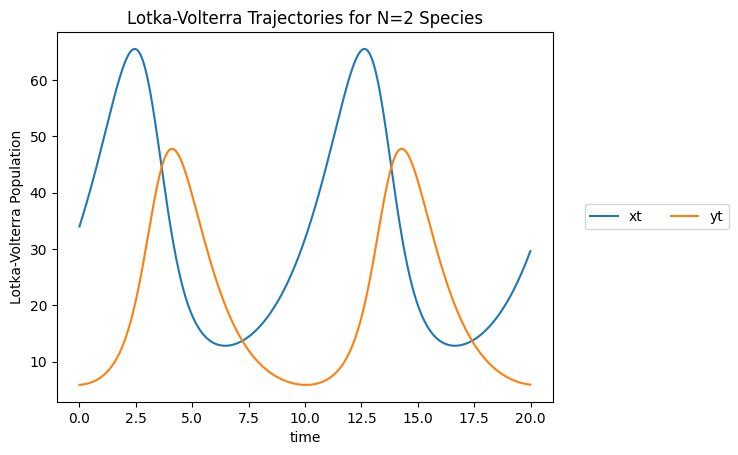

In [7]:
glv_df.plot(x = 'time')

plt.ylabel('Lotka-Volterra Population')
plt.title(f'Lotka-Volterra Trajectories for N={n_species} Species')
plt.legend(bbox_to_anchor=(1.05, 0.5), ncol=2, loc='center left')

plt.savefig(os.path.join(plots_glv_path, "glv_original_data.png"))

# Helper Functions Across Methods

In [8]:
def regular_mse(pred_df, true_df):
  """
  pred_df: dataframe of predictions of shape (n_timepoints, n_genes)
  true_df: dataframe of true values of shape (n_timepoints, n_genes)
  """

  return np.mean((true_df - pred_df) ** 2)


def pooled_mse(pred_df, true_df):
  """
  pred_df: dataframe of predictions of shape (n_timepoints, n_genes)
  true_df: dataframe of true values of shape (n_timepoints, n_genes)
  """

  return np.mean(np.mean((pred_df - true_df) ** 2, axis = 0))



In [9]:
def binarize(x):
  if x > 0:
    return 1
  elif x < 0:
    return -1
  else:
    return 0

def compare_coupling(pred_df, true_df):
  """
  pred_df: dataframe of predictions of shape (n_timepoints, n_genes)
  true_df: dataframe of true values of shape (n_timepoints, n_genes)
  """
  binary_pred = pred_df.map(binarize)
  return np.linalg.norm(binary_pred - true_df)



In [10]:
true_adjacency = pd.DataFrame(A, index = ['xt', 'yt'], columns = ['xt', 'yt'])
true_adjacency

,xt,yt
xt,0.000,-0.026
yt,0.026,0.000


# Transform Data

In [11]:
glv_df.shape

(2000, 3)

In [12]:
# Get colnames
clock_cols = glv_df\
  .drop(['time'], axis = 1, inplace = False)\
  .columns.tolist()


In [12]:
len(clock_cols)

2

# MOGP

## MOGP Configs

In [13]:
TRAIN_HIST = 15

## MOGP Data Prep

In [14]:
mogptk_data = mogptk.DataSet()

for i, clock_col in enumerate(clock_cols):
    mogptk_data.append(mogptk.Data(glv_df['time'], glv_df[clock_col], name = clock_col))
    mogptk_data.transform(mogptk.TransformDetrend(degree=1))
    mogptk_data[i].remove_range(start = TRAIN_HIST)
    # mogptk_data[i].remove_range(start = 0, end = 30)
    # mogptk_data[i] # remove frome nd

(<Figure size 1200x800 with 2 Axes>,
 array([[<AxesSubplot:title={'center':'xt'}, xlabel='X', ylabel='Y'>],
        [<AxesSubplot:title={'center':'yt'}, xlabel='X', ylabel='Y'>]],
       dtype=object))

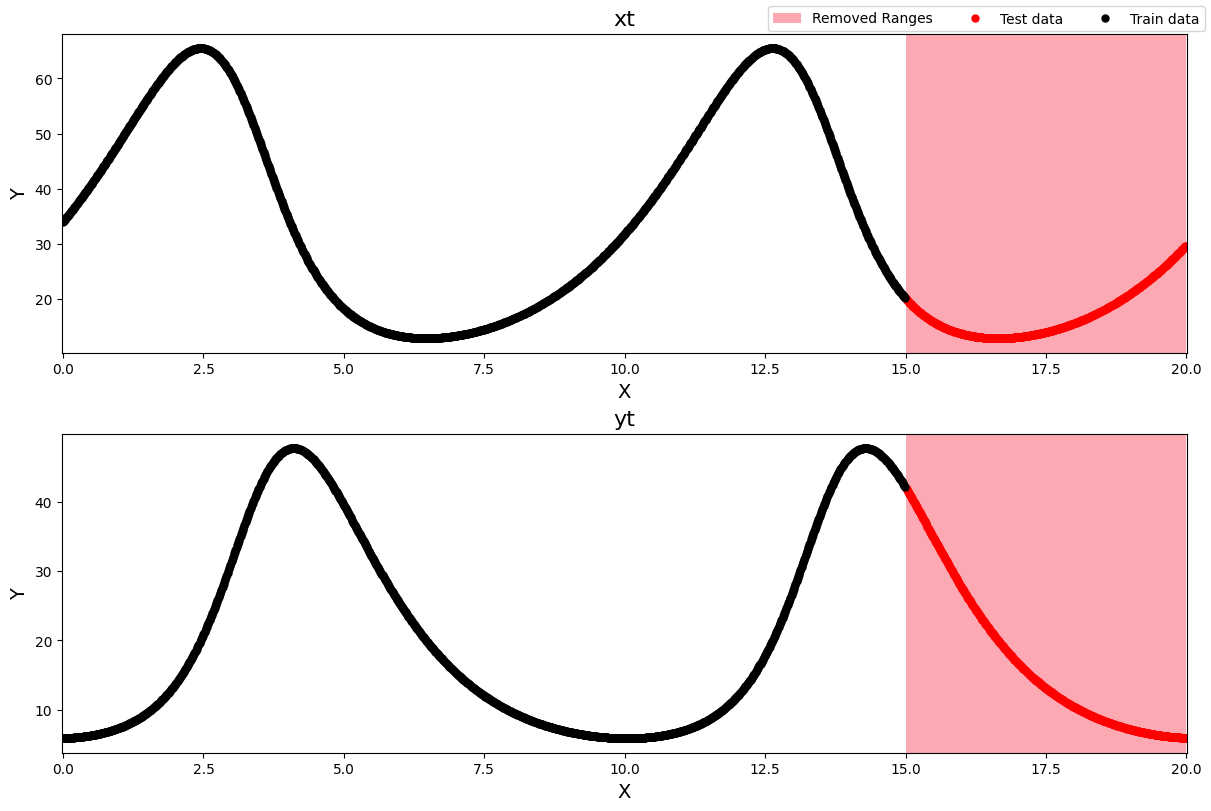

In [15]:
mogptk_data.plot()

## MOGP Training

In [48]:
# create model, uncomment for different kernels
mogptk_model = mogptk.MOSM(mogptk_data, Q=2)
# mogptk_model = mogptk.CSM(mogptk_data, Q=4)
# mogptk_model = mogptk.SM_LMC(mogptk_data, Q=2)
# mogptk_model = mogptk.CONV(mogptk_data)

# initialize parameters of kernel using LombScargle
mogptk_model.init_parameters(method='SM', iters=60)

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 22
‣ Training points: 3000
‣ Iterations: 100
    0/100   0:00:00  loss=     11379.8  error=     116.917
   10/100   0:00:10  loss=     11266.3  error=     145.192
   19/100   0:00:20  loss=     11239.2  error=     197.598
   29/100   0:00:30  loss=       11209  error=     254.731
   39/100   0:00:40  loss=     11179.1  error=     268.069
   49/100   0:00:50  loss=     11149.4  error=     261.809
   59/100   0:01:00  loss=     11119.4  error=     263.595
   69/100   0:01:10  loss=     11089.2  error=     263.526
   79/100   0:01:20  loss=     11058.7  error=     257.484
   89/100   0:01:30  loss=       11028  error=     254.391
   99/100   0:01:40  loss=       10997  error=     252.282
  100/100   0:01:41  loss=     10993.9  error=     252.042
Optimization finished in 1 minute 41 seconds


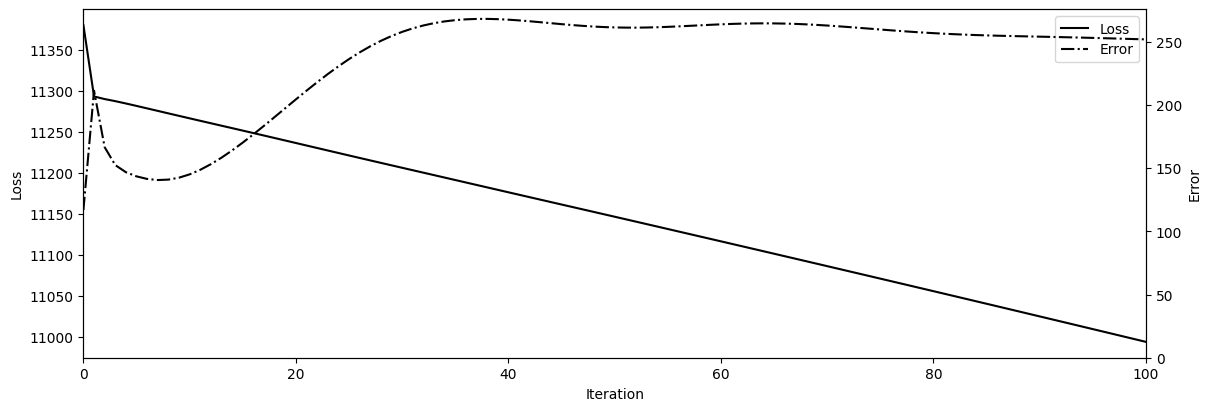

In [49]:
# MOSM
mogptk_model.train(method='Adam', lr=0.02, iters=100, plot=True, error='MSE', verbose=True);

In [35]:
# LMC
# mogptk_model.train(method='Adam', lr=0.02, iters=100, plot=True, error='MSE', verbose=True);

Starting optimization using Adam
‣ Model: Exact
  ‣ Kernel: MultiOutputSpectralMixtureKernel
  ‣ Likelihood: GaussianLikelihood
‣ Channels: 2
‣ Parameters: 22
‣ Training points: 3000
‣ Iterations: 100
   10/110   0:00:01  loss=     11266.2  error=     145.437
   20/110   0:00:10  loss=       11231  error=     255.705
   30/110   0:00:21  loss=     11200.1  error=     250.681
   39/110   0:00:30  loss=     11173.2  error=     234.665


KeyboardInterrupt: 

## MOGP Prediction

### Capture predictions in dataframe

In [38]:
mogptk_time, mogptk_mu, mogptk_lower_ci, mogptk_upper_ci = mogptk_model.predict(
    X=None,
    ci=None,
    sigma=2,
    n=10000,
    transformed=False
)

In [39]:
mogptk_mu[0].shape

(2000,)

In [40]:
mogptk_preds_df = pd.DataFrame(mogptk_mu,
                               index = glv_df.iloc[:, 1:].columns.tolist()).T
mogptk_preds_df.insert(0, 'time', glv_df['time'].values)
mogptk_preds_df

,time,xt,yt
0,0.00,39.885798,8.700637
1,0.01,39.898097,8.629441
2,0.02,39.912466,8.558662
3,0.03,39.928906,8.488312
4,0.04,39.947416,8.418405
...,...,...,...
1995,19.95,2.353380,1.126441
1996,19.96,2.490199,1.185773
1997,19.97,2.629211,1.245330
1998,19.98,2.770415,1.305113


### Modifying MOGPTK plot_prediction


Want to plot a square facet grid

In [41]:
def plot_prediction(mogptk_model,
                    X=None,
                    title=None,
                    figsize=None,
                    legend=True,
                    errorbars=True,
                    nrows = None,
                    ncols = None,
                    suptitle=None,
                    supfontsize=40,
                    subfontsize=20,
                    ci=None,
                    sigma=2,
                    n=10000,
                    transformed=False):
    """
    Plot the data including removed observations, latent function, and predictions of this model for each channel.

    Args:
        X (list, dict): Array of shape (data_points,), (data_points,input_dims), or [(data_points,)] * input_dims per channel with prediction X values. If a dictionary is passed, the index is the channel index or name.
        title (str): Set the title of the plot.
        figsize (tuple): Set the figure size.
        legend (boolean): Disable legend.
        errorbars (boolean): Plot data error bars if available.
        ci (float,list of float): Confidence interval as a percentage or the two quantile limits [lower, upper] in the range of [0,1].
        sigma (float): Number of standard deviations to display upwards and downwards.
        n (int): Number of samples used from distribution to estimate quantile.
        transformed (boolean): Display transformed Y data as used for training.

    Returns:
        matplotlib.figure.Figure: The figure.
        list of matplotlib.axes.Axes: List of axes.

    Examples:
        >>> fig, axes = dataset.plot(title='Title')
    """
    X, Mu, Lower, Upper = mogptk_model.predict(X, ci=ci, sigma=sigma, n=n, transformed=transformed)
    if len(mogptk_model.dataset) == 1:
        X = [X]
        Mu = [Mu]
        Lower = [Lower]
        Upper = [Upper]

    if figsize is None:
        figsize = (12,4*len(mogptk_model.dataset))

    if nrows == None and ncols == None:
        nrows = len(mogptk_model.dataset)
        ncols = 1

    fig, ax = plt.subplots(nrows = nrows,
                           ncols = ncols,
                           figsize=figsize,
                           squeeze=False,
                           constrained_layout=True)
    for j, data in enumerate(mogptk_model.dataset):
        r, c = divmod(j, ncols)

        # TODO: ability to plot conditional or marginal distribution to reduce input dims
        if data.get_input_dims() > 2:
            raise ValueError("cannot plot more than two input dimensions")
        if data.get_input_dims() == 2:
            raise NotImplementedError("two dimensional input data not yet implemented") # TODO

        legends = []
        if errorbars and data.Y_err is not None:
            x, y = data.get_train_data(transformed=transformed)
            yl = data.Y[data.mask] - data.Y_err[data.mask]
            yu = data.Y[data.mask] + data.Y_err[data.mask]
            if transformed:
                yl = data.Y_transformer.forward(yl, x)
                yu = data.Y_transformer.forward(yu, x)
            x = x.astype(data.X_dtypes[0])
            ax[j,0].errorbar(x, y, [y-yl, yu-y], elinewidth=1.5, ecolor='lightgray', capsize=0, ls='', marker='')

        # prediction
        idx = np.argsort(X[j][:,0])
        x = X[j][idx,0].astype(data.X_dtypes[0])
        ax[r, c].plot(x, Mu[j][idx], ls=':', color='blue', lw=2)
        if not np.all(Lower[j][idx] == Mu[j][idx]) and not np.all(Upper[j][idx] == Mu[j][idx]):
            ax[r, c].fill_between(x, Lower[j][idx], Upper[j][idx], color='blue', alpha=0.3)
            legends.append(patches.Rectangle(
                (1, 1), 1, 1, fill=True, color='blue', alpha=0.3, lw=0, label='95% Error Bars'
            ))
        legends.append(plt.Line2D([0], [0], ls=':', color='blue', lw=2, label='Posterior Mean'))

        xmin = min(np.min(data.X), np.min(X[j]))
        xmax = max(np.max(data.X), np.max(X[j]))
        if data.F is not None:
            if np.issubdtype(data.X_dtypes[0], np.datetime64):
                dt = np.timedelta64(1,data.X.get_time_unit())
                n = int((xmax-xmin) / dt) + 1
                x = np.arange(xmin, xmax+np.timedelta64(1,'us'), dt, dtype=data.X_dtypes[0])
            else:
                n = len(data.X)*10
                x = np.linspace(xmin, xmax, n)

            y = data.F(x)
            if transformed:
                y = data.Y_transformer.forward(y, x)

            ax[r, c].plot(x, y, 'g--', lw=1)
            legends.append(plt.Line2D([0], [0], ls='--', color='g', label='Latent'))

        if data.has_test_data():
            x, y = data.get_test_data(transformed=transformed)
            x = x.astype(data.X_dtypes[0])
            ax[r, c].plot(x, y, 'r.', ms=10)
            legends.append(plt.Line2D([0], [0], ls='', color='r', marker='.', ms=10, label='Test data'))

        x, y = data.get_train_data(transformed=transformed)
        x = x.astype(data.X_dtypes[0])
        ax[r, c].plot(x, y, 'k.', ms=10)
        legends.append(plt.Line2D([0], [0], ls='', color='k', marker='.', ms=10, label='Train data'))

        if 0 < len(data.removed_ranges[0]):
            for removed_range in data.removed_ranges[0]:
                x0 = removed_range[0].astype(data.X_dtypes[0])
                x1 = removed_range[1].astype(data.X_dtypes[0])
                y0 = ax[r, c].get_ylim()[0]
                y1 = ax[r, c].get_ylim()[1]
                ax[r, c].add_patch(patches.Rectangle(
                    (x0, y0), x1-x0, y1-y0, fill=True, color='xkcd:strawberry', alpha=0.4, lw=0,
                ))
            legends.insert(0, patches.Rectangle(
                (1, 1), 1, 1, fill=True, color='xkcd:strawberry', alpha=0.4, lw=0, label='Removed Ranges'
            ))

        xmin = xmin.astype(data.X_dtypes[0])
        xmax = xmax.astype(data.X_dtypes[0])
        ax[r, c].set_xlim(xmin-(xmax-xmin)*0.001, xmax+(xmax-xmin)*0.001)
        ax[r, c].set_xlabel(data.X_labels[0])
        ax[r, c].set_ylabel(data.Y_label)
        ax[r, c].set_title(data.name if title is None else title, fontsize=subfontsize)

        ax[r, c].tick_params(axis='both', which='major', labelsize=34)
        ax[r, c].tick_params(axis='both', which='minor', labelsize=30)


        # plt.legend(handles=legends[::-1])
    fig.supxlabel('Time', fontsize = 50)
    fig.supylabel('Population Size', fontsize = 50)
    fig.suptitle(suptitle, fontsize=supfontsize)

    if legend:
      fig.legend(handles=legends[::-1], bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize= 50)
    return fig, ax

<ipython-input-42-6798bad6d53b>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_glv2_q2_mosm.png"))
<ipython-input-42-6798bad6d53b>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_glv2_q2_mosm.png"))
<ipython-input-42-6798bad6d53b>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_glv2_q2_mosm.png"))
<ipython-input-42-6798bad6d53b>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported

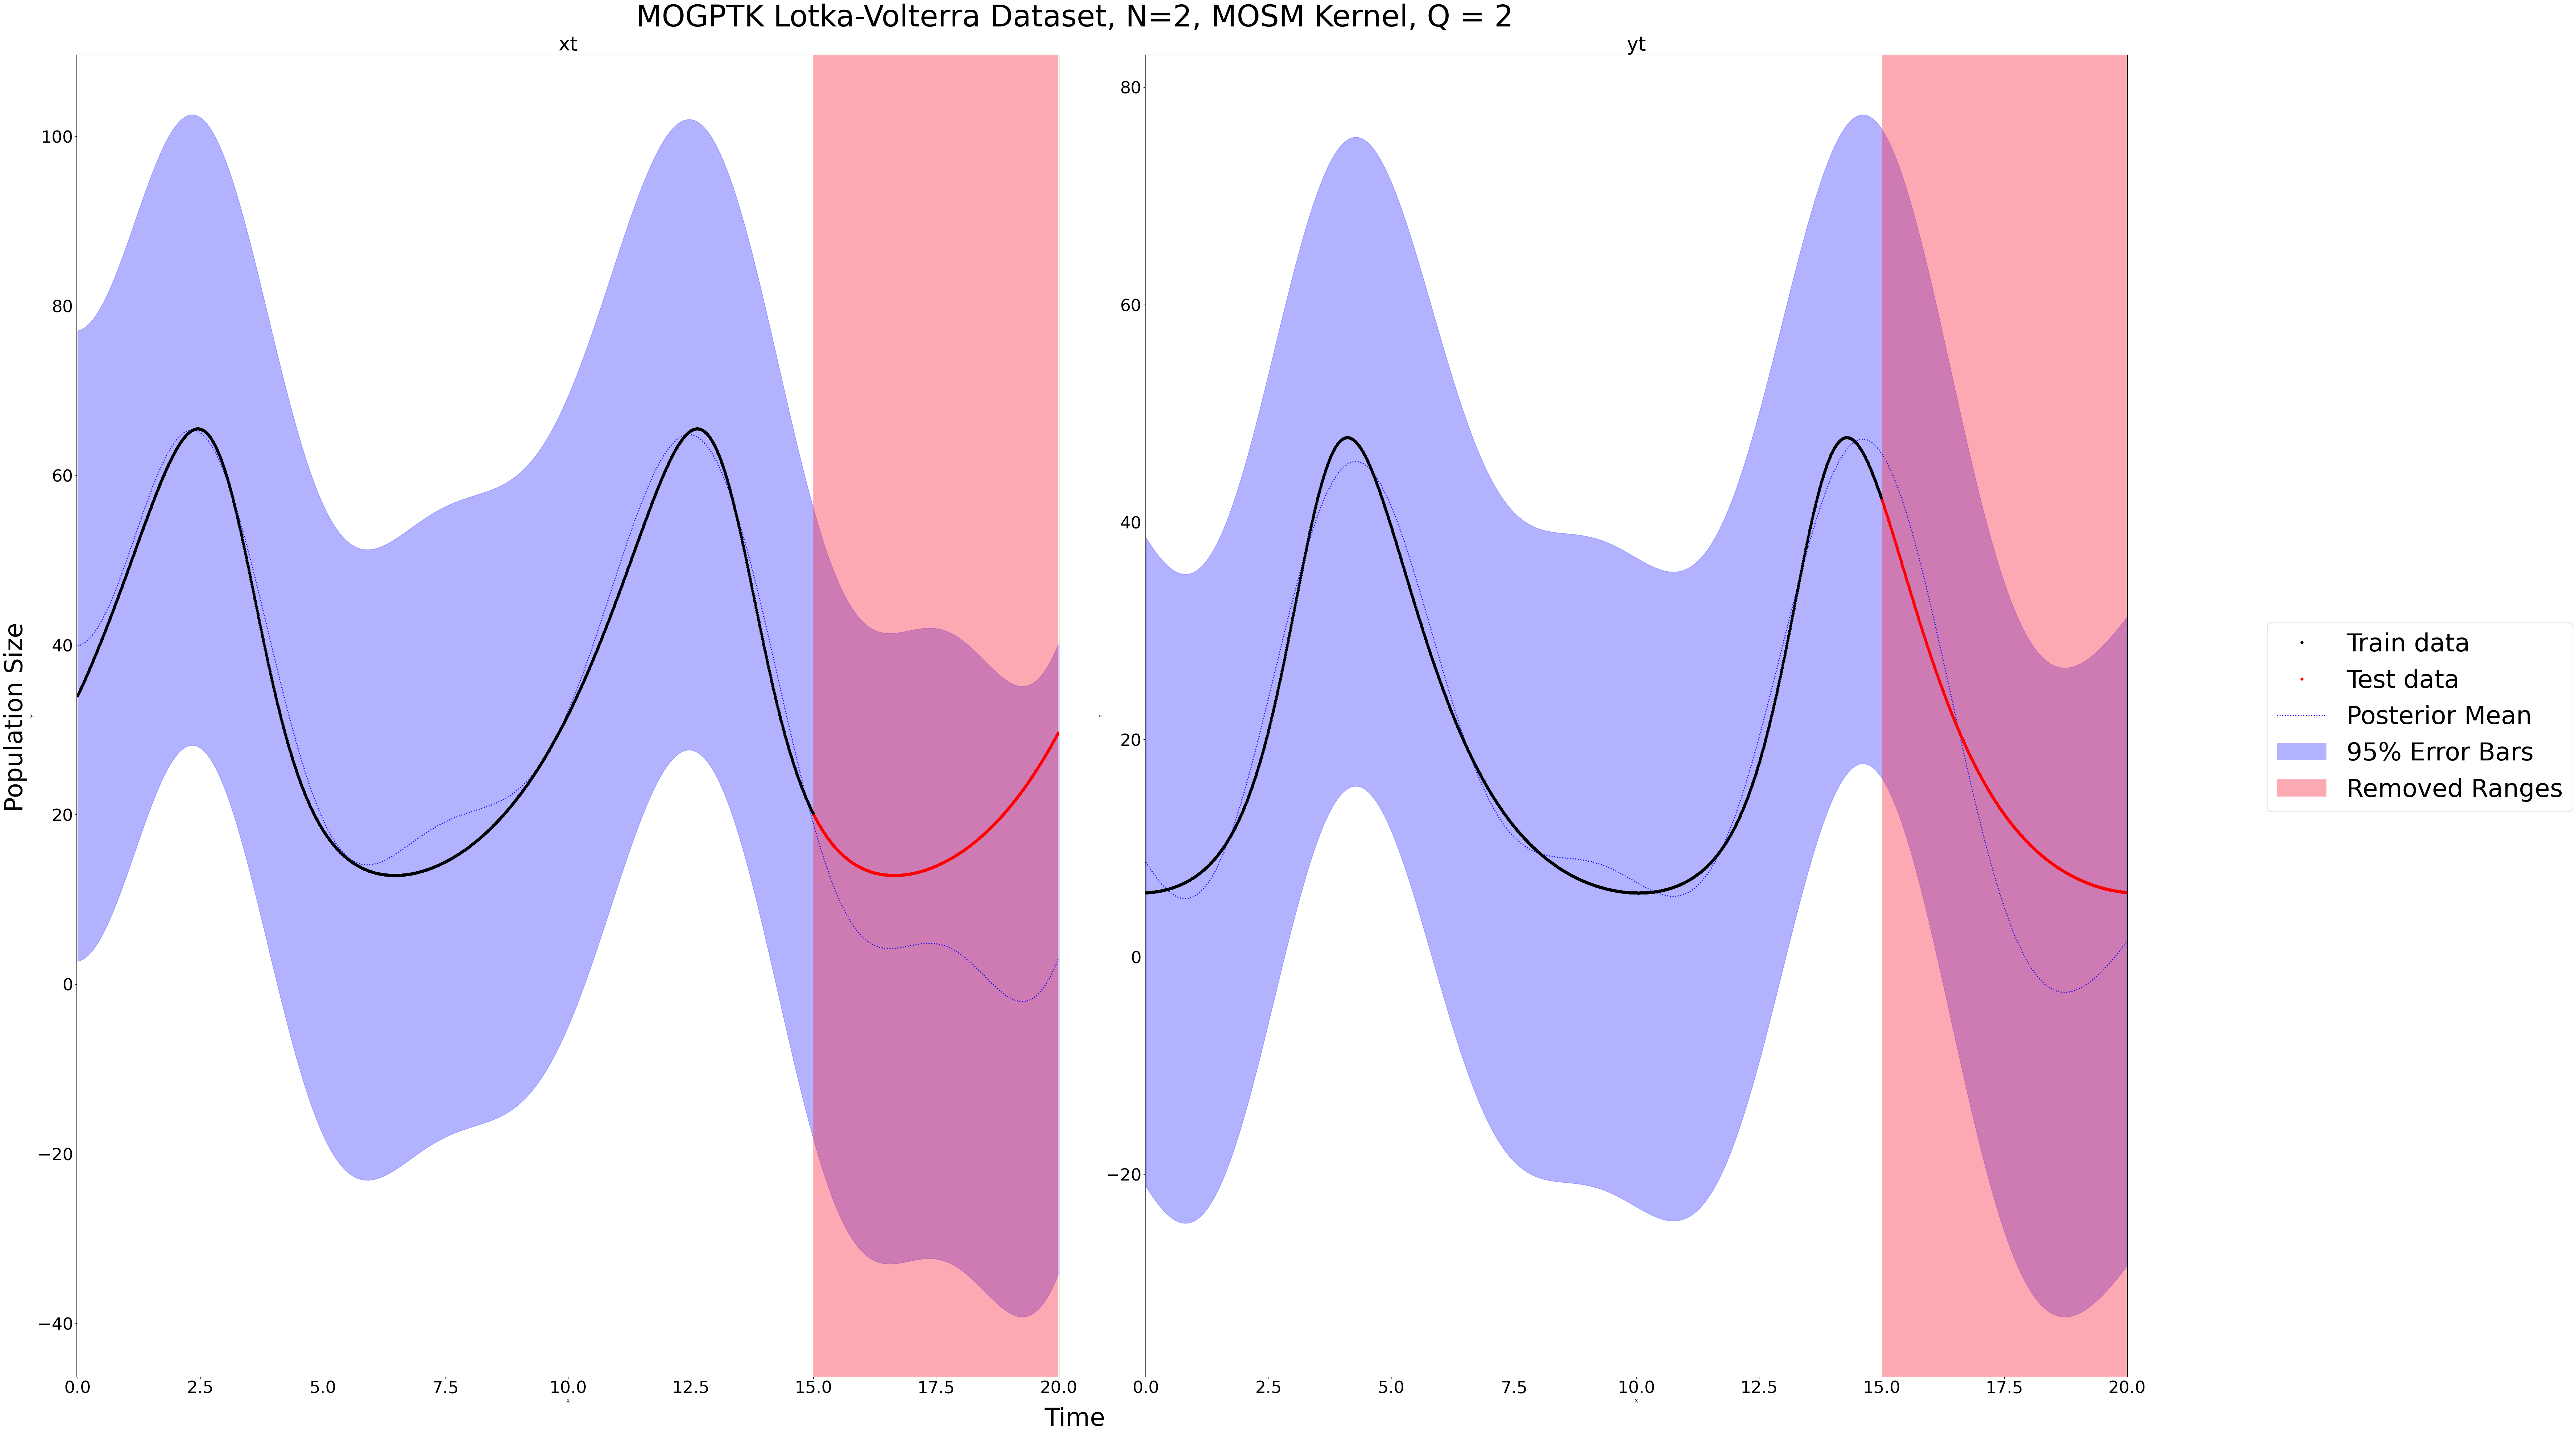

In [42]:
suptitle = 'MOGPTK Lotka-Volterra Dataset, N=2, MOSM Kernel, Q = 2'

plot_prediction(mogptk_model = mogptk_model,
                nrows = 1,
                ncols = 2,
                figsize = (60, 40),
                suptitle = suptitle,
                supfontsize=60,
                subfontsize= 40)

plt.savefig(os.path.join(plots_glv_path, "mogptk_glv2_q2_mosm.png"))
plt.show()

In [ ]:
mogptk_model.print_parameters()

Name,Range,Value
MultiOutputSpectralMixtureKernel.weight,"[1e-08, ∞)",[[5564.52109076 981.64305058] [4382.1617337 449.69092402]]
MultiOutputSpectralMixtureKernel.mean,"[1e-08, 50.000000000001066]",[[[0.10102577] [0.14401421]] [[0.08431913] [0.24499148]]]
MultiOutputSpectralMixtureKernel.variance,"[1e-08, ∞)",[[[0.00052422] [0.00043931]] [[0.00046886] [0.00040986]]]
MultiOutputSpectralMixtureKernel.delay,"(-∞, ∞)",[[[ 0.10406903] [ 0.13195395]] [[-0.10406903] [-0.13195395]]]
MultiOutputSpectralMixtureKernel.phase,"(-∞, ∞)",[[ 0.00770496 0.13325919] [-0.00770496 -0.13325919]]
GaussianLikelihood.scale,"[1e-08, ∞)",[16.81554988 13.30362419]


## MOGP Covariance Matrix

In [43]:
# K = self.gpr.K(X).cpu().numpy()

# # normalise
# diag_sqrt = np.sqrt(np.diag(K))
# K /= np.outer(diag_sqrt, diag_sqrt)


output_dims = len(mogptk_model.dataset)
X_ = np.zeros((output_dims, 2))
X_[:,0] = np.arange(output_dims)
K = mogptk_model.gpr.K(X_).cpu().numpy()

# normalize
diag_sqrt = np.sqrt(np.diag(K))
K /= np.outer(diag_sqrt, diag_sqrt)

# Transform numpy array to dataframe
gene_cols = glv_df.iloc[:, 1:].columns.tolist()
mogptk_covariance_df = pd.DataFrame(K, index = gene_cols, columns = gene_cols)

mogptk_covariance_df

,xt,yt
xt,1.000000,0.026647
yt,0.026647,1.000000


<ipython-input-45-3adc6e7d543a>:6: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_bnse_heatmap.png"))
<ipython-input-45-3adc6e7d543a>:6: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_bnse_heatmap.png"))
<ipython-input-45-3adc6e7d543a>:6: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_bnse_heatmap.png"))
<ipython-input-45-3adc6e7d543a>:6: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which

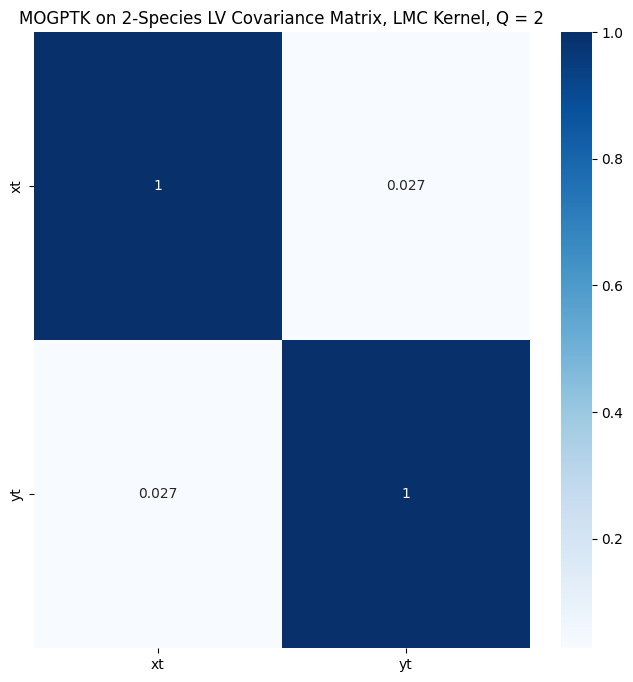

In [45]:
plt.figure(figsize=(8,8))
sns.heatmap(mogptk_covariance_df,
            cmap = 'Blues',
            annot=True, xticklabels=True, yticklabels=True)
plt.title('MOGPTK on 2-Species LV Covariance Matrix, LMC Kernel, Q = 2')
plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_bnse_heatmap.png"))



## Visualizing Weights and Magnitude

In [24]:

input_dims = mogptk_model.dataset.get_input_dims()[0]
output_dims = mogptk_model.dataset.get_output_dims()
Q = mogptk_model.Q

cross_params = {}
cross_params['covariance'] = np.zeros((output_dims, output_dims, input_dims, Q))
cross_params['mean'] = np.zeros((output_dims, output_dims, input_dims, Q))
cross_params['magnitude'] = np.zeros((output_dims, output_dims, Q))
cross_params['delay'] = np.zeros((output_dims, output_dims, input_dims, Q))
cross_params['phase'] = np.zeros((output_dims, output_dims, Q))

weight = mogptk_model.gpr.kernel.weight.numpy()
mean = mogptk_model.gpr.kernel.mean.numpy()
variance = mogptk_model.gpr.kernel.variance.numpy()
phase = mogptk_model.gpr.kernel.phase.numpy()
delay = mogptk_model.gpr.kernel.delay.numpy()
for q in range(Q):
    for i in range(output_dims):
        for j in range(output_dims):
            w_i = weight[i,q]
            w_j = weight[j,q]
            mu_i = mean[i,q,:]
            mu_j = mean[j,q,:]
            var_i = variance[i,q,:]
            var_j = variance[j,q,:]
            sv = var_i + var_j

            cross_params['covariance'][i, j, :, q] = 2 * (var_i * var_j) / sv
            cross_mean_num = var_i.dot(mu_j) + var_j.dot(mu_i)
            cross_params['mean'][i, j, :, q] = cross_mean_num / sv
            exp_term = -1/4 * ((mu_i - mu_j)**2 / sv).sum()
            cross_params['magnitude'][i, j, q] = w_i * w_j * np.exp(exp_term)
            for k in range(input_dims):
                cross_params['delay'][i, j, k, q] = delay[i,q,k]-delay[j,q,k]
            cross_params['phase'][i, j, q] = phase[i,q]-phase[j,q]

<ipython-input-32-2a1186678fab>:8: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_magnitude.png"))
<ipython-input-32-2a1186678fab>:8: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_magnitude.png"))
<ipython-input-32-2a1186678fab>:8: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_magnitude.png"))
<ipython-input-32-2a1186678fab>:8: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no lo

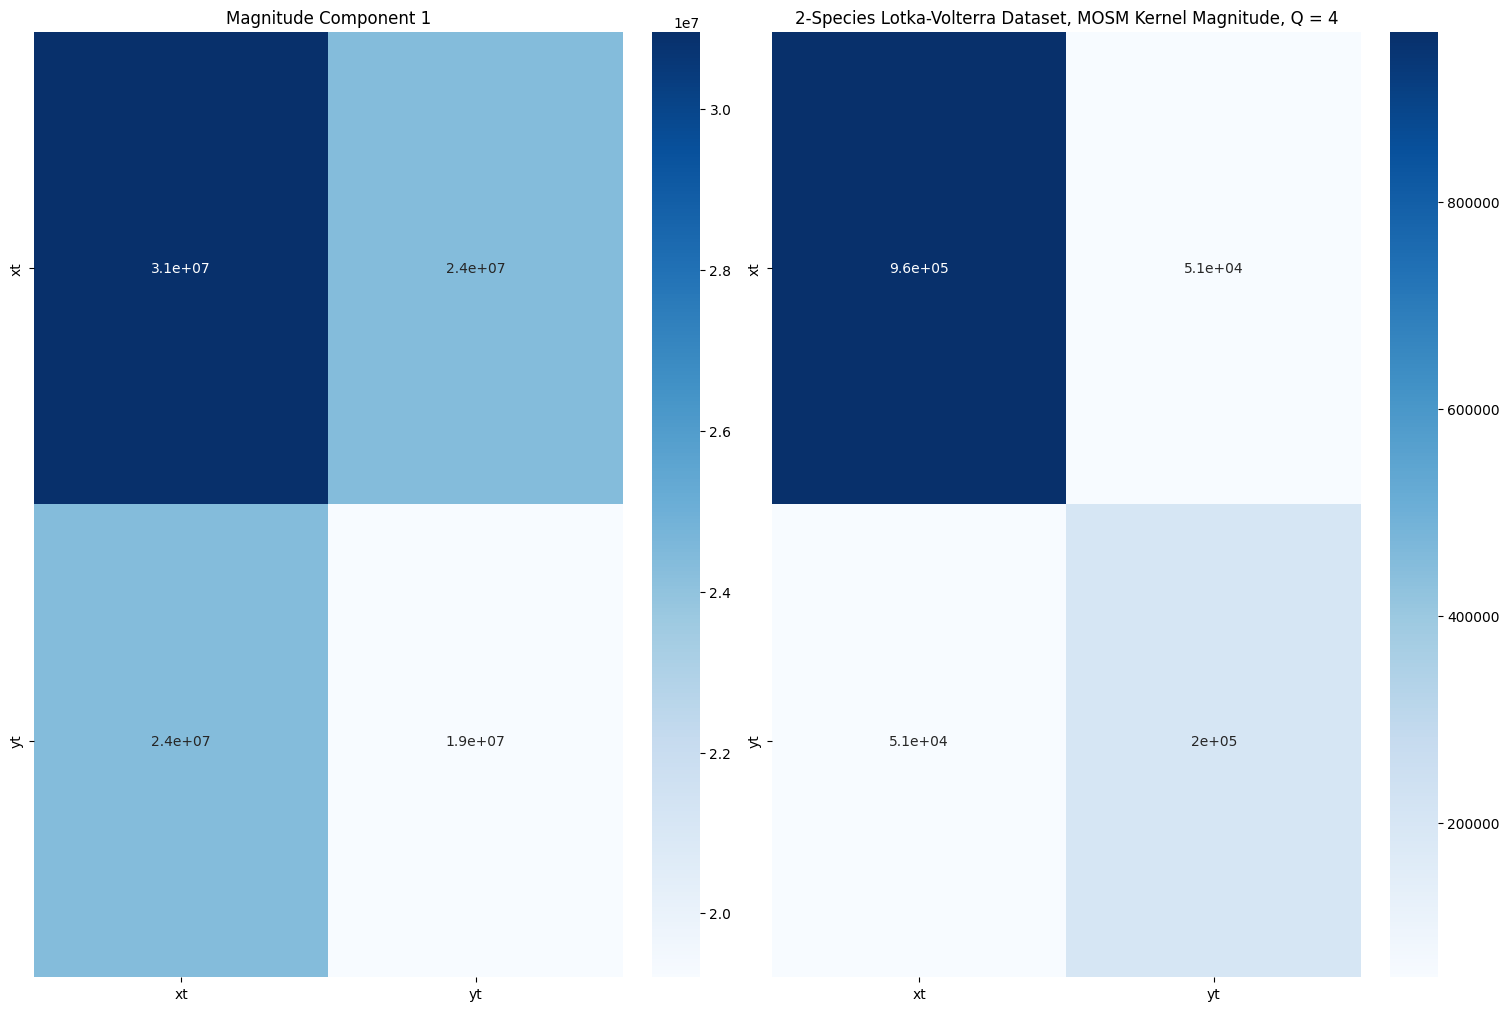

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(15, 10), layout = "constrained")
for i in range(Q):
  r, c = divmod(i, 2)
  sns.heatmap(pd.DataFrame(cross_params['magnitude'][:, :, i], columns=gene_cols, index=gene_cols), annot = True, cmap = 'Blues', xticklabels=True, yticklabels=True, ax = ax[i])
  ax[i].set_title(f"Magnitude Component {i+1}")

plt.title("2-Species Lotka-Volterra Dataset, MOSM Kernel Magnitude, Q = 4")
plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_glv_magnitude.png"))

<ipython-input-31-3b6c15e71352>:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_tempo2_weights.png"))
<ipython-input-31-3b6c15e71352>:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_tempo2_weights.png"))
<ipython-input-31-3b6c15e71352>:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_tempo2_weights.png"))
<ipython-input-31-3b6c15e71352>:14: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which i

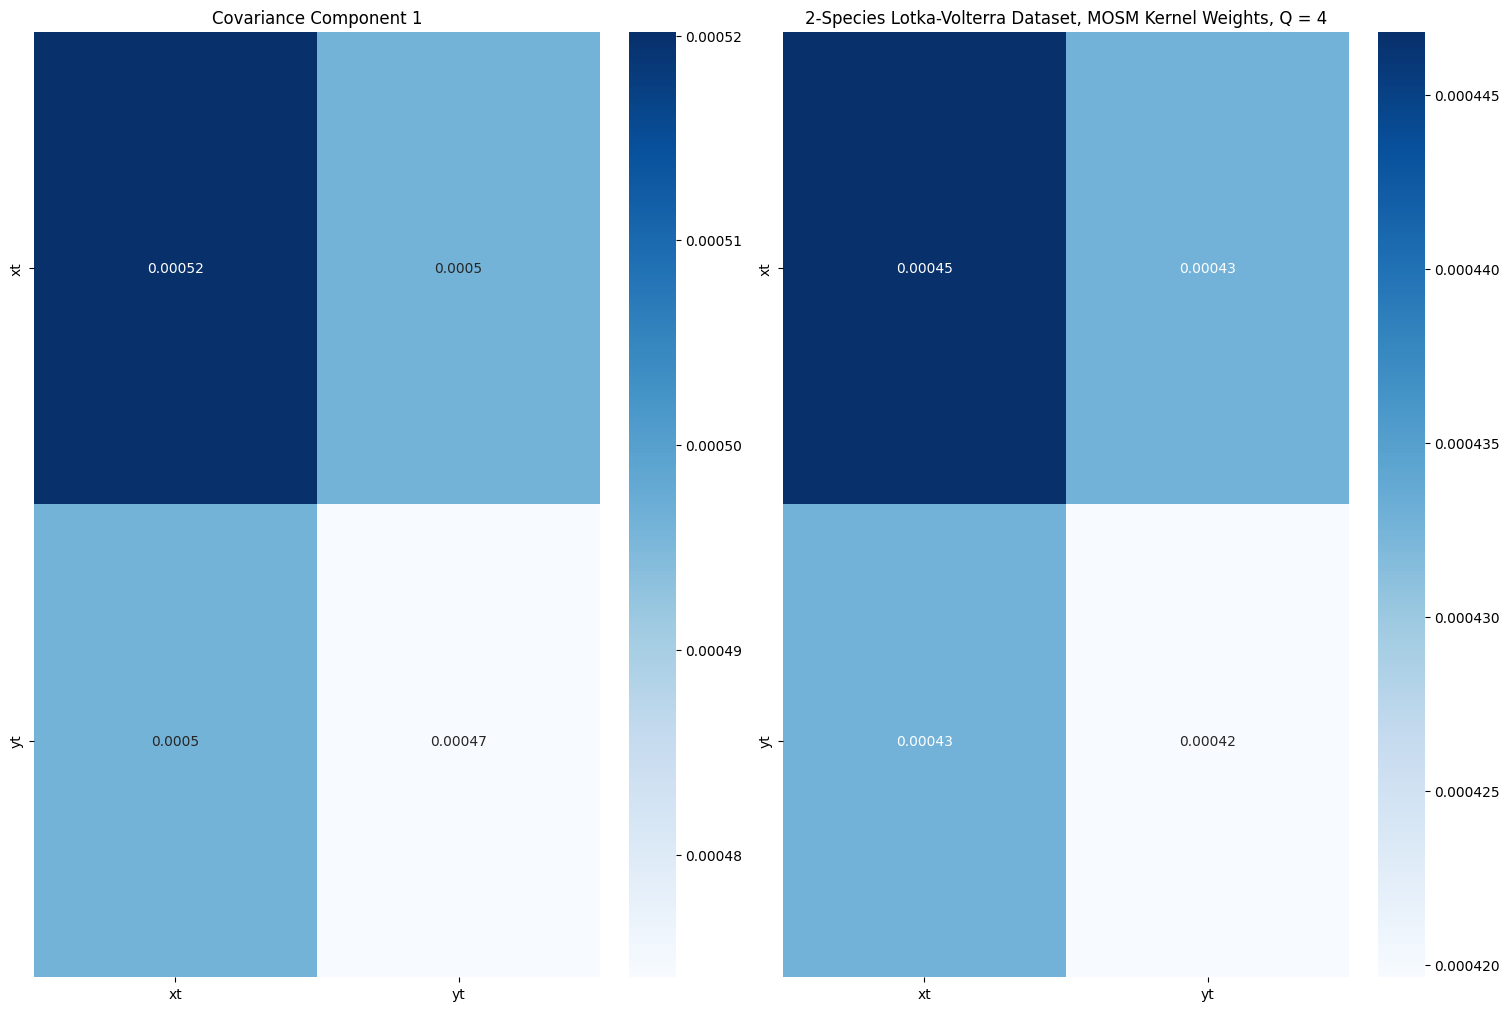

In [31]:
weights = dict()

for i in range(Q):
  weights[i] = cross_params['covariance'][:, :, 0, i]


fig, ax = plt.subplots(1, 2, figsize=(15, 10), layout = "constrained")
for i in range(Q):
  r, c = divmod(i, 2)
  sns.heatmap(pd.DataFrame(weights[i], columns=gene_cols, index=gene_cols), cmap = 'Blues', annot = True, xticklabels=True, yticklabels=True, ax = ax[i])
  ax[i].set_title(f"Covariance Component {i+1}")

plt.title("2-Species Lotka-Volterra Dataset, MOSM Kernel Weights, Q = 4")
plt.savefig(os.path.join(plots_glv_path, "mogptk_mosm_tempo2_weights.png"))

## MOGP Performance Metrics

In [50]:
mogptk_pooled_mse = pooled_mse(pred_df = mogptk_preds_df.iloc[:, 1:],
                                true_df = glv_df.iloc[:, 1:])
mogptk_r2 = r2_score(y_true = glv_df.iloc[:, 1:], y_pred = mogptk_preds_df.iloc[:, 1:])
mogptk_coupling = compare_coupling(pred_df = mogptk_covariance_df,
                 true_df = true_adjacency)

print(f"The Pooled MSE of the MOGPTK Model is {mogptk_pooled_mse}.")
print(f"The R^2 of the MOGPTK Model is {mogptk_r2}.")
print(f"The Coupling of the MOGPTK Model is {mogptk_coupling}.")

The Pooled MSE of the MOGPTK Model is 39.538161254168216.
The R^2 of the MOGPTK Model is 0.8635689267335367.
The Coupling of the MOGPTK Model is 2.000337971443826.


# NCDE (Noise-Perturbed)

## NCDE Configs

In [39]:
# Data params
N_SNAPSHOTS = 5000 # number of observations
N_TIMEPOINTS = glv_df.shape[0] # number of datapoints

# Model params
HIDDEN_SIZE = 16
WIDTH_SIZE = 32 # The size of each hidden layer.
OUTPUT_SIZE = glv_df.shape[1] - 1 # output size, which here is the number of genes we want to output. # features = # genes = # columns in waves_df - 1 (because of time column)
DEPTH = 8
SEED = 12314
KEY = jr.PRNGKey(SEED)
train_data_key, test_data_key, model_key, loader_key = jr.split(KEY, 4)

add_noise = False
BATCH_SIZE = 32
lr = 1e-2
steps = 500

# Suppose we have lag-p auto-regressors
WINDOW_LENGTH = 4000
STEPSIZE = 10
NCDE_TRAIN_HIST_PROP = 0.8

## Helper Functions + Specify Model

In [40]:
# First, define the function which will specify the vector field of
# the differential equation.
class Func(eqx.Module):
    mlp: eqx.nn.MLP
    data_size: int
    hidden_size: int

    def __init__(self, data_size, hidden_size, width_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        self.data_size = data_size
        self.hidden_size = hidden_size
        self.mlp = eqx.nn.MLP(
            hidden_size,
            hidden_size * data_size,
            width_size,
            depth,
            activation=jnn.tanh,
            # Note the use of a tanh final activation function. This is important to
            # stop the model blowing up. (Just like how GRUs and LSTMs constrain the
            # rate of change of their hidden states.)
            final_activation=jnn.tanh,
            key=key,
        )

    def __call__(self, t, y, args):
        return self.mlp(y).reshape(self.hidden_size, self.data_size)

# The above Func will be solved as part of the NeuralCDE algo
# Below. Note we do have an MLP for the initial condition
# As well as the future iterations.

class NeuralCDE(eqx.Module):
    initial: eqx.nn.MLP
    func: Func
    linear: eqx.nn.Linear

    def __init__(self, data_size, hidden_size, width_size, output_size, depth, *, key, **kwargs):
        super().__init__(**kwargs)
        ikey, fkey, lkey = jr.split(key, 3)
        self.initial = eqx.nn.MLP(in_size = data_size,
                                  out_size = hidden_size,
                                  width_size = width_size,
                                  depth = depth,
                                  key = ikey)
        self.func = Func(data_size, hidden_size, width_size, depth, key=fkey)
        self.linear = eqx.nn.Linear(hidden_size, output_size, key=lkey)

    def __call__(self, ts, coeffs, evolving_out=False):
        # Each sample of data consists of some timestamps `ts`, and some `coeffs`
        # parameterising a control path. These are used to produce a continuous-time
        # input path `control`.
        control = diffrax.CubicInterpolation(ts, coeffs) # X term
        print(f"Finished control with {control}")
        term = diffrax.ControlTerm(self.func, control).to_ode() # dXt term in NCDE
        solver = diffrax.Tsit5()
        dt0 = None
        y0 = self.initial(control.evaluate(ts[0]))

        print(f"ts[0] shape: {ts[0].shape}")
        print(f"y0 shape: {y0.shape}")

        if evolving_out:
            saveat = diffrax.SaveAt(ts=ts)
        else:
            saveat = diffrax.SaveAt(t1=True)
        solution = diffrax.diffeqsolve(
            term,
            solver,
            ts[0],
            ts[-1],
            dt0,
            y0,
            stepsize_controller=diffrax.PIDController(rtol=1e-3, atol=1e-6),
            saveat=saveat,
        )

        # return solution.ys, y0
        if evolving_out:
            # applies self.linear to every value of y (meaning at every timepoint)
            prediction = jax.vmap(lambda y: self.linear(y))(solution.ys) # jax.vmap(lambda y: jnn.tanh(self.linear(y)[0])(solution.ys)
        else:
            # print(f"solution.ys has shape {solution.ys.shape}")
            prediction = self.linear(solution.ys[-1]) # jnn.tanh(self.linear(solution.ys[-1])) # (prediction, )
        return prediction

# Data Processing Functions
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size

def window_stack(df, width=3, stepsize=1):
    """
    Takes in waves_df (T, G) dimension (T = # timepoints, G = # genes)
    and slides a window of length width (W), sliding over on stepsize at a time,
    to return two datasets:

    1. Jax array of feature vectors, size (T - W, G, W)
    2. Jax array of target vectors, size (T - W, G, 1)
    """

    dat = df.drop(labels = 'time', axis = 1) # remove time column
    dat = dat.T # transpose from [time, genes] to [genes, time]
    dat = dat.values # only gets values, which will make us lose gene index
    max_T = dat.shape[1] # number of timepoints
    range_T = df.time.to_list() # store all timepoints in a list

    # Create windowed Jax array for features (technically autoregressors)
    feat_window_list = [dat[:, k: (k + width)] for k in range(0, max_T - width, stepsize)]
    feat_window_jnp = jnp.array(feat_window_list) # turns this into a Jax array of size [T - W, G, W]
    feat_window_jnp = jnp.moveaxis(feat_window_jnp, -1, -2) # transposes last two axis so we get [T - W, W, G]

    # Prep timepoints to be stacked with the features, as this is a requirement for the diffrax training method
    time_window_jnp = jnp.array([range_T[k:k + width] for k in range(0, max_T - width, stepsize)]) # size [T - W, W]
    time_windowed = jnp.expand_dims(time_window_jnp, -1) # to [T - W, W, 1]

    # Concatenate (T - W, W, G) tensor of features with (T - W, W, 1) tensor of time to get a (T - W, W, G + 1) tensor of features + time
    x_windowed = jnp.concatenate([time_windowed, feat_window_jnp], axis = -1)

    # Create windowed Jax array for target (= response) variables
    target_window_list = [dat[:, k + width] for k in range(0, max_T - width, stepsize)]
    target_window_jnp = jnp.array(target_window_list) # turns into a Jax array of size [T - W, G]
    y_windowed = jnp.expand_dims(target_window_jnp, -2) # makes it same dimensionality as feat_window_jnp, i.e., [T - W, G] to [T - W, 1, G]

    return x_windowed, y_windowed, time_windowed

# Modeling Functions
def train_test_split(X, y, t, pct_hist):
    max_T = X.shape[0]
    hist_cutoff = int(max_T * pct_hist)

    X_hist, y_hist, t_hist = X[:hist_cutoff, :, :], y[:hist_cutoff, :, :], t[:hist_cutoff, :, :]
    X_future, y_future, t_future = X[hist_cutoff:, :, :], y[hist_cutoff:, :, :], t[hist_cutoff:, :, :]

    return X_hist, y_hist, t_hist, X_future, y_future, t_future


def cubic_spline_interpolation(X_stack, t_stack):
    # Do cubic spline interpolation to get X
    if t_stack.ndim == 3:
        t_stack = t_stack[:, :, 0]

    coeffs = jax.vmap(diffrax.backward_hermite_coefficients)(t_stack, X_stack)

    return coeffs

## Data Transformations for Training

In [41]:
dinner_noise_iter = []

for i in range(N_SNAPSHOTS):
  dinner_wo_time = glv_df.iloc[:, 1:] # shape :  (n_timepoints, n_genes)
  noise = np.random.normal(0, 0.001, dinner_wo_time.shape)
  dinner_wo_time = dinner_wo_time + noise # (n_timepoints, n_genes + 1)

  dinner_noise_iter.append(dinner_wo_time)

dinner_noise_iter = np.stack(dinner_noise_iter) # (n_shapshots, n_timepoints, n_genes + 1)

dinner_noise_iter.shape

(5000, 2000, 2)

In [42]:
# Get a 1D vector of timepoints from the dataset
t_vec = glv_df['time'].values.reshape(-1, 1)
print(f"Shape of t_vec: {t_vec.shape}")
# repeat over N_SNAPSHOTS rows to prep for the NCDE training format
t_mat = np.tile(t_vec, (N_SNAPSHOTS, 1, 1))
print(f"Shape of t_mat: {t_mat.shape}")
# Prep it for training by removing the third dimension and remove last timepoint to fit training X_waveforms later
t_mat2d = t_mat[:, :N_TIMEPOINTS - 1, 0]
print(f"Shape of the t_mat2d is currently {t_mat2d.shape}.")

# Concatenate training data with timestamps to create waveforms_all
waveforms_all = jnp.concatenate([t_mat, dinner_noise_iter], axis = -1)
print(f"Shape of the waveforms_all is currently {waveforms_all.shape}")

# Split data into X and y
X_waveforms = waveforms_all[:, :N_TIMEPOINTS - 1, :]
y_waveforms = dinner_noise_iter[:, N_TIMEPOINTS - 1:, :]
y_waveforms_evol = dinner_noise_iter[:, :N_TIMEPOINTS - 1, :]
print(f"Created X_waveforms with shape {X_waveforms.shape} and y_waveforms with shape {y_waveforms.shape}.")

# Create cubic spline over X
coeffs = cubic_spline_interpolation(X_waveforms, t_mat2d)
print(f"Length of the coefficients is currently {len(coeffs)} with each element having shape {coeffs[0].shape}.")


Shape of t_vec: (2000, 1)
Shape of t_mat: (5000, 2000, 1)
Shape of the t_mat2d is currently (5000, 1999).
Shape of the waveforms_all is currently (5000, 2000, 3)
Created X_waveforms with shape (5000, 1999, 3) and y_waveforms with shape (5000, 1, 2).
Length of the coefficients is currently 4 with each element having shape (5000, 1998, 3).


## Train NCDE Model

### Run: 4/13/2025 7:04 PM, 500 steps, Depth = 4 (2x)

Finished control with CubicInterpolation(
  ts=f32[1999], coeffs=[f32[1998,3], f32[1998,3], f32[1998,3], f32[1998,3]]
)
ts[0] shape: ()
y0 shape: (16,)
y_true: (32, 1999, 2); y_pred: (32, 1999, 2).
Step: 0, Loss: 894.92333984375, Accuracy: 894.92333984375, Computation time: 92.83062767982483
Step: 1, Loss: 891.12646484375, Accuracy: 891.12646484375, Computation time: 3.6507115364074707
Step: 2, Loss: 887.974365234375, Accuracy: 887.974365234375, Computation time: 3.5755317211151123
Step: 3, Loss: 884.0550537109375, Accuracy: 884.0550537109375, Computation time: 3.6617822647094727
Step: 4, Loss: 880.3314208984375, Accuracy: 880.3314208984375, Computation time: 3.782933473587036
Step: 5, Loss: 877.3668212890625, Accuracy: 877.3668212890625, Computation time: 3.8165841102600098
Step: 6, Loss: 873.5044555664062, Accuracy: 873.5044555664062, Computation time: 3.729602098464966
Step: 7, Loss: 870.0933227539062, Accuracy: 870.0933227539062, Computation time: 3.8766839504241943
Step: 8, Loss: 

<ipython-input-43-9be96ce1f7b6>:139: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "neural_glv_cde.png"))
<ipython-input-43-9be96ce1f7b6>:139: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "neural_glv_cde.png"))
<ipython-input-43-9be96ce1f7b6>:139: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "neural_glv_cde.png"))
<ipython-input-43-9be96ce1f7b6>:139: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 

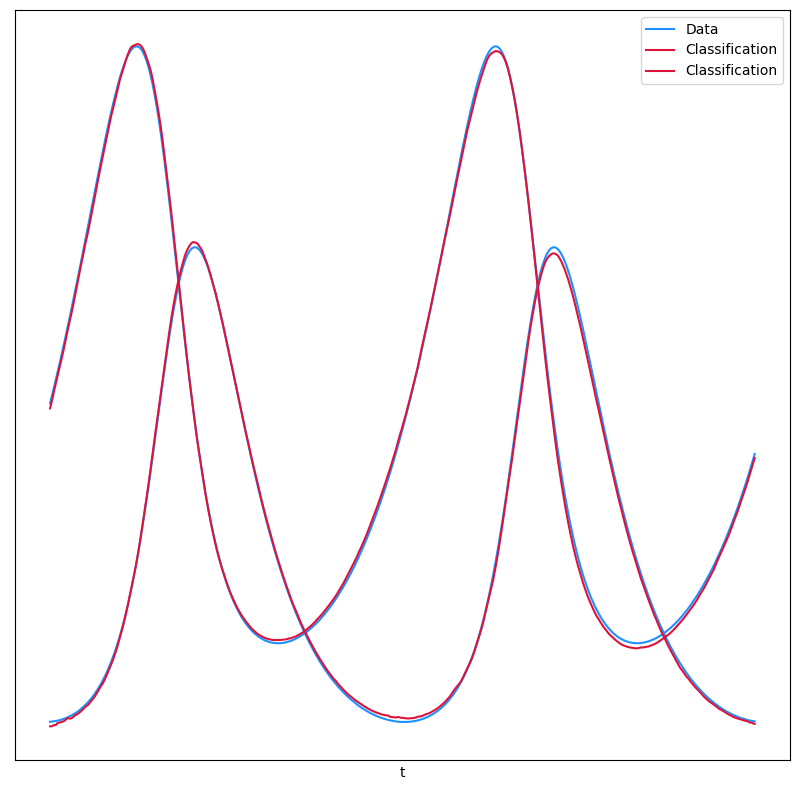

In [43]:
import time

# Training loop like normal.
### Model Instantiation ###
# NeuralCDEV2 is a class that takes in an (N, T - 1, G) tensor and the network architecture params.
# When instantiated (as done below)
model_sim = NeuralCDE(data_size = X_waveforms.shape[-1],
                      hidden_size = HIDDEN_SIZE,
                      width_size = WIDTH_SIZE,
                      output_size = OUTPUT_SIZE,
                      depth = DEPTH,
                      key = model_key)

### FUNCTIONS ###
def ncde_predict(model, ti, coeff_i, evolving_out = False):
    if evolving_out:
        def model_evolving(ts, coeffs):
            return model(ts, coeffs, evolving_out = True)
        return jax.vmap(model_evolving)(ti, coeff_i)
    else:
        return jax.vmap(model)(ti, coeff_i)

def compute_mse(y_true, y_pred, epsilon=1e-15):
    """
    MSE Loss for forecasting with real numbers
    """
    # if y_true.ndim == 3:
    #     y_true = y_true[:, 0, :]

    # Ensure predictions are clipped to avoid log(0)
    # y_pred = jnp.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate the categorical cross-entropy
    # loss = jnp.mean(optax.l2_loss(y_pred, y_true))
    loss = jnp.mean((y_true - y_pred)**2, axis=1)

    # Return the mean loss over all samples
    return jnp.mean(loss)

@eqx.filter_jit
def loss(model, ti, y_true, coeff_i, evolving_out = False):
    pred = ncde_predict(model, ti, coeff_i, evolving_out = evolving_out)

    print(f"y_true: {y_true.shape}; y_pred: {pred.shape}.")

    # MSE
    mse_val = compute_mse(y_true = y_true, y_pred = pred)

    # mse_val = jnp.mean(mse_val)

    return mse_val, mse_val

# has_aux true will return two values: output to be differentiated and its gradient
grad_loss = eqx.filter_value_and_grad(loss, has_aux=True)

@eqx.filter_jit
def make_step(model, data_i, opt_state):
    ti, label_i, label_all_i, *coeff_i = data_i

    (mse_val, _), grads = grad_loss(model, ti, label_all_i, coeff_i, evolving_out = True)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return mse_val, model, opt_state

# Data Processing Functions
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size


### EXECUTION ###
# Optional section
optim = optax.adam(1e-4)
opt_state = optim.init(eqx.filter(model_sim, eqx.is_inexact_array))
for step, data_i in zip(
    range(steps), dataloader((t_mat2d, y_waveforms, y_waveforms_evol) + coeffs, BATCH_SIZE, key=loader_key)
):
    start = time.time()
    mse_val, model_sim, opt_state = make_step(model_sim, data_i, opt_state)
    end = time.time()
    print(
        f"Step: {step}, Loss: {mse_val}, Accuracy: {mse_val}, Computation time: "
        f"{end - start}"
    )

# ts, coeffs, labels, _ = get_data(dataset_size, add_noise, key=test_data_key)
(mse_val, _) = loss(model = model_sim,
                    ti = t_mat2d,
                    y_true = y_waveforms,
                    coeff_i = coeffs)
print(f"Test loss: {mse_val}, Test Accuracy: {mse_val}")

# Plot results : Data Preparation for Plotting
sample_ts = t_mat2d[-1] # gets the last waveform in the dataset [size: (N_TIMEPOINTS - 1,)]
# coeffs is a list of four tensors for each cubic spliene coefficient,
# so we get, for each coefficient tensor, the last row which is the coefficients of the last tensor
sample_coeffs = tuple(c[-1] for c in coeffs)
# Get predictions for that waveform
pred = model_sim(sample_ts, sample_coeffs, evolving_out=True)
# This interpolates data for the coefficients
interp = diffrax.CubicInterpolation(sample_ts, sample_coeffs)
# Evaluates sample time series for the actual values
values = jax.vmap(interp.evaluate)(sample_ts)

# Plot 1
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(sample_ts, values[:, 1], c="dodgerblue")
ax1.plot(sample_ts, values[:, 2], c="dodgerblue", label="Data")
ax1.plot(sample_ts, pred, c="crimson", label="Classification")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xlabel("t")
ax1.legend()

# Plot 2
# ax2 = fig.add_subplot(1, 2, 2, projection="3d")
# ax2.plot(values[:, 1], values[:, 2], c="dodgerblue", label="Data")
# ax2.plot(values[:, 1], values[:, 2], pred[:, 1], c="crimson", label="Classification")
# ax2.set_xticks([])
# ax2.set_yticks([])
# ax2.set_zticks([])
# ax2.set_xlabel("x")
# ax2.set_ylabel("y")
# ax2.set_zlabel("Classification")
plt.tight_layout()
plt.savefig(os.path.join(plots_glv_path, "neural_glv_cde.png"))
plt.show()

## Plot Predictions

Finished control with CubicInterpolation(
  ts=f64[1999](numpy),
  coeffs=(f32[1998,3], f32[1998,3], f32[1998,3], f32[1998,3])
)
ts[0] shape: ()
y0 shape: (16,)


<ipython-input-44-054ef611a054>:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'ncde_glv2_d4_ep500_l32.png'))
<ipython-input-44-054ef611a054>:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'ncde_glv2_d4_ep500_l32.png'))
<ipython-input-44-054ef611a054>:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'ncde_glv2_d4_ep500_l32.png'))
<ipython-input-44-054ef611a054>:40: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer 

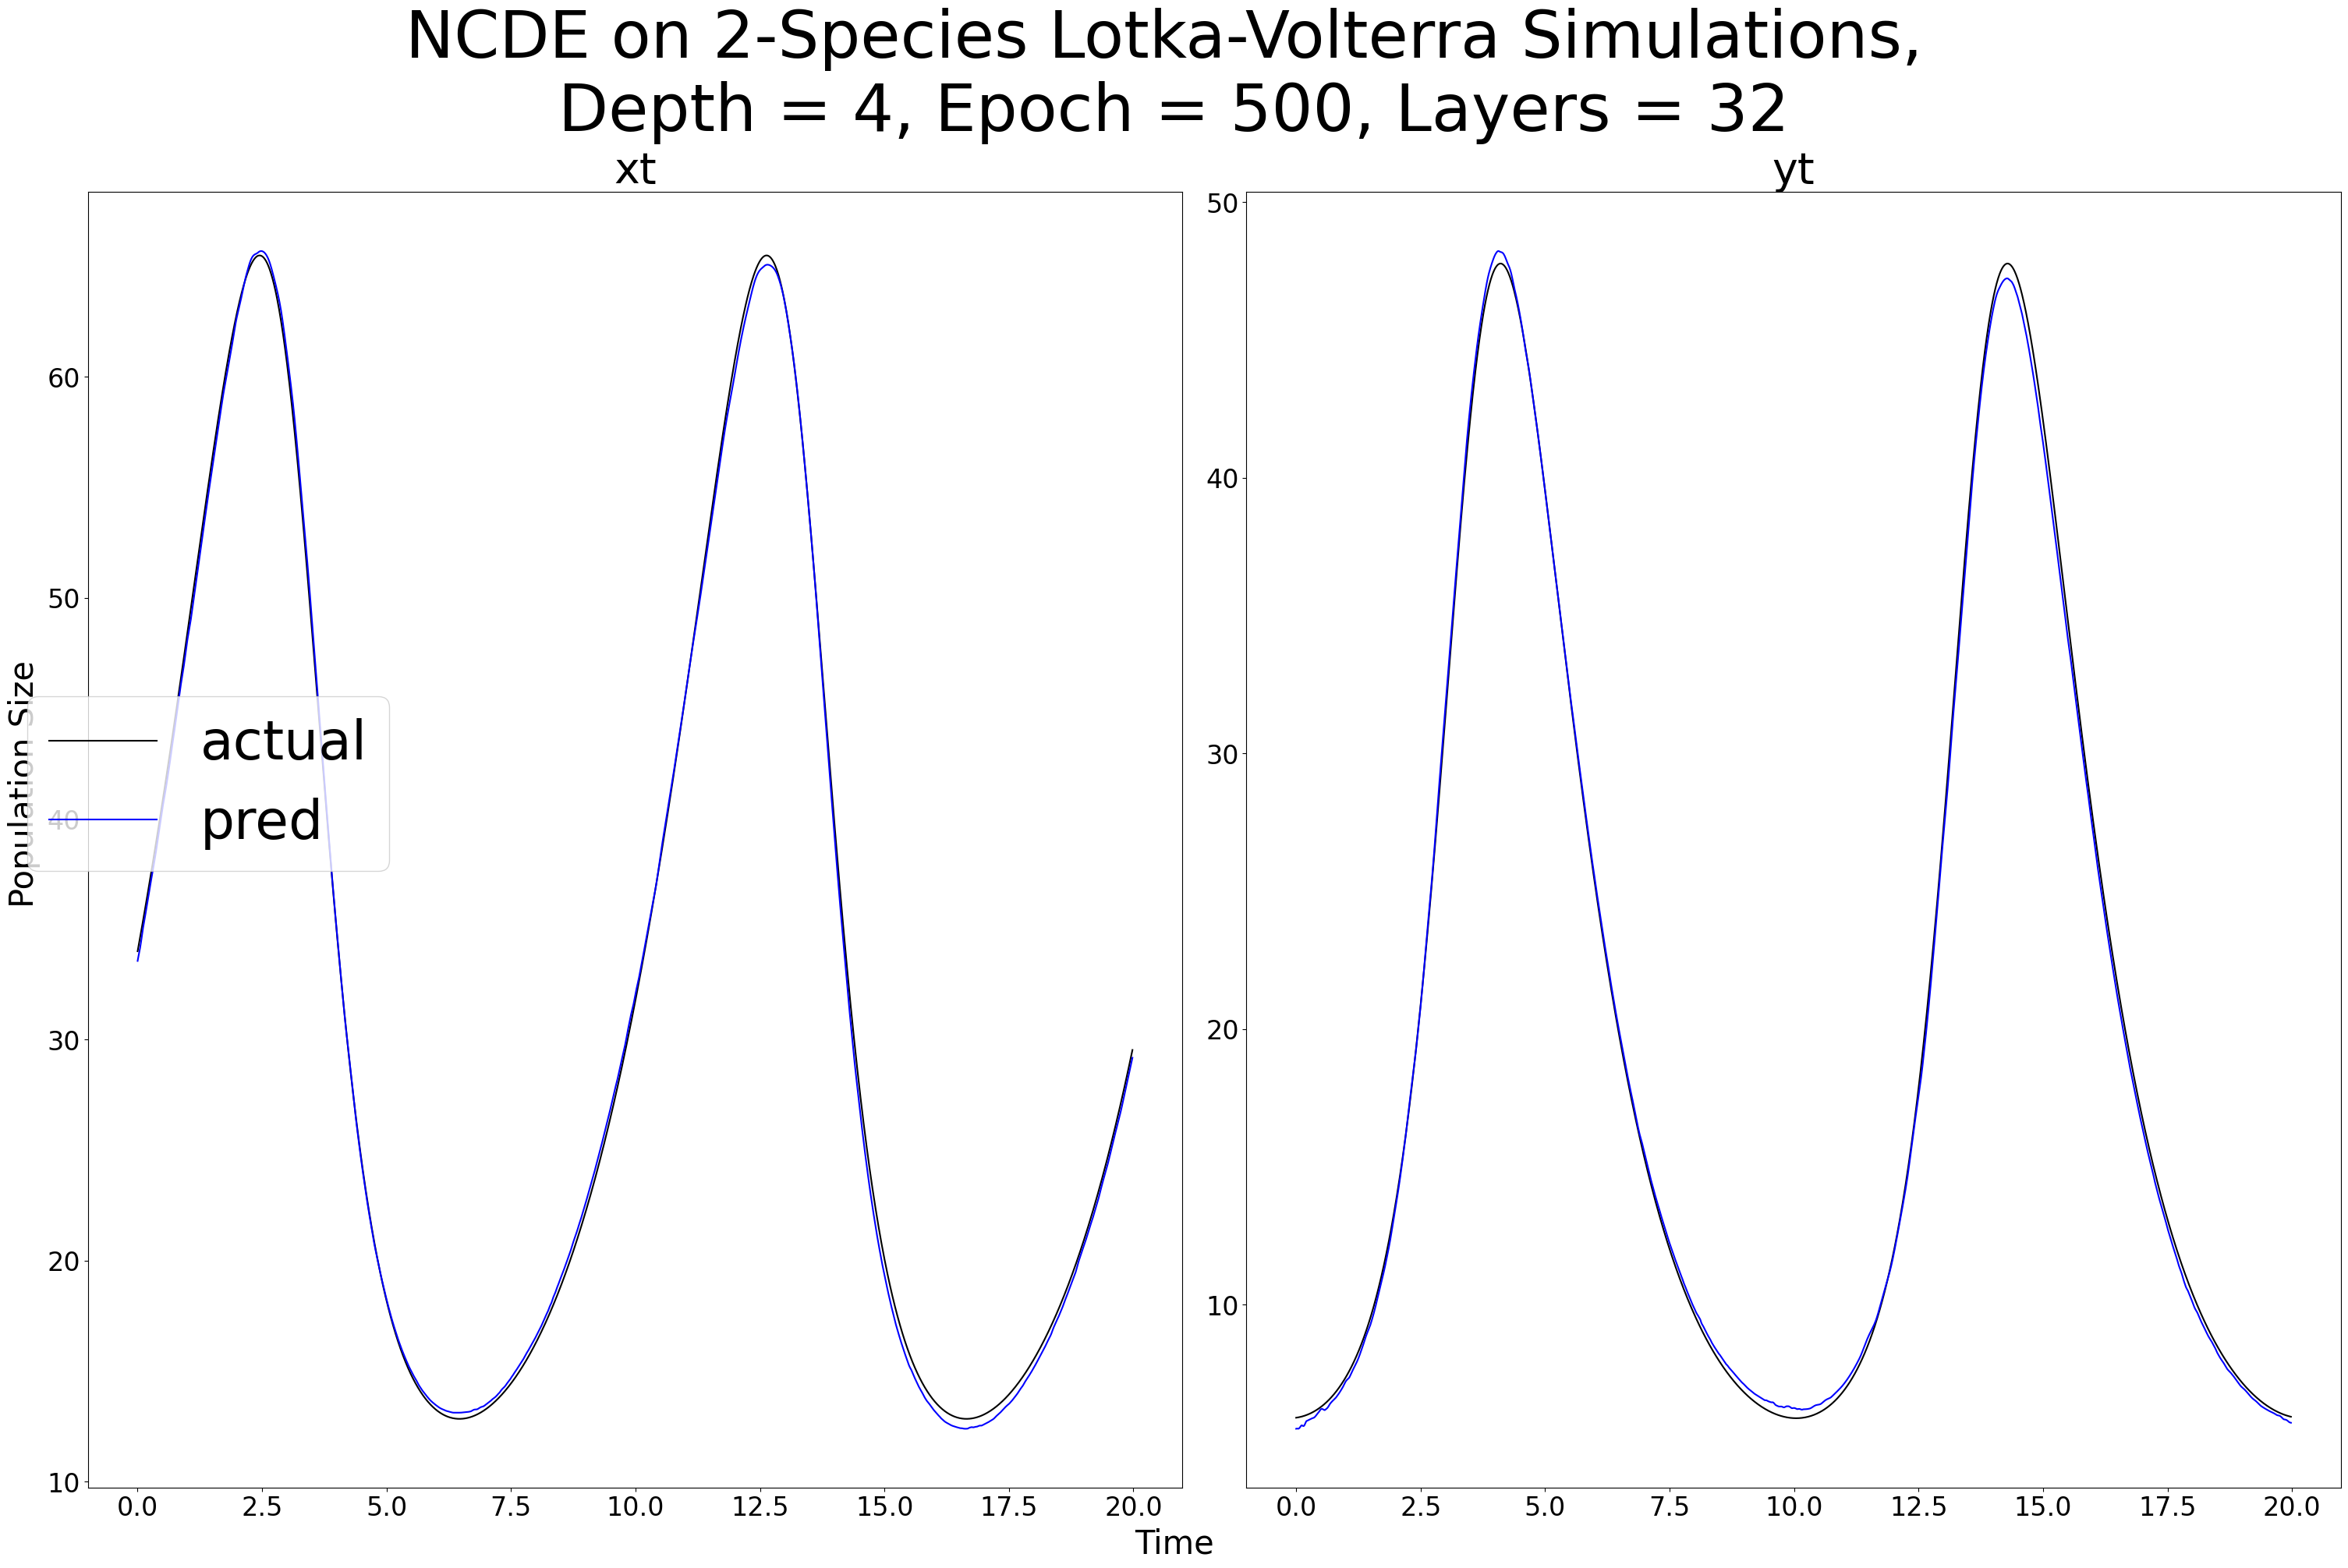

In [44]:
gene_cols = glv_df.iloc[:, 1:].columns.tolist()

ncde_pred_df = model_sim(sample_ts, sample_coeffs, evolving_out=True)
ncde_pred_df = pd.DataFrame(ncde_pred_df, columns = gene_cols)

fig, ax = plt.subplots(1, 2, figsize = (30, 20), layout = "constrained")

for col in range(ncde_pred_df.shape[1]):

  colname = gene_cols[col]

  actual_data = glv_df.iloc[:-1, :].loc[:, colname].values
  pred_data = ncde_pred_df[colname].values

  sample_pred_df = pd.DataFrame({'t': sample_ts, 'actual': actual_data, 'pred': pred_data})
  sample_pred_df = sample_pred_df.sort_values(by = 't', ascending = True)

  ax[col].plot(sample_pred_df['t'].values,
                sample_pred_df['actual'].values,
                label = 'actual',
                color = 'black')
  ax[col].plot(sample_pred_df['t'].values,
                sample_pred_df['pred'].values,
                label = 'pred',
                color = 'blue')
  ax[col].set_title(colname, fontsize = 40)

  ax[col].tick_params(axis='both', which='major', labelsize=24)
  ax[col].tick_params(axis='both', which='minor', labelsize=20)


fig.supxlabel('Time', fontsize = 30)
fig.supylabel('Population Size', fontsize = 30)

handles, labels = ax[col].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', fontsize= 50) # , bbox_to_anchor=(1.05, 0.5)

suptitle_ncde = 'NCDE on 2-Species Lotka-Volterra Simulations, \nDepth = 4, Epoch = 500, Layers = 32'
plt.suptitle(suptitle_ncde, fontsize = 60)
plt.savefig(os.path.join(plots_glv_path, 'ncde_glv2_d4_ep500_l32.png'))
plt.show()


## Performance Metrics

### Pooled MSE

In [45]:
ncde_pooled_mse = pooled_mse(ncde_pred_df, glv_df.iloc[:-1, 1:])

### R2

In [46]:
ncde_r2 = r2_score(y_true = glv_df.iloc[:-1, 1:], y_pred = ncde_pred_df)

In [47]:
print(f"Pooled MSE: {ncde_pooled_mse}")
print(f"R2: {ncde_r2}")

Pooled MSE: 0.12518198796338456
R2: 0.9995122136131527


# Koopman

## Koopman Configs

In [48]:
# Data params
N_SNAPSHOTS = 1000 # number of observations
N_TIMEPOINTS = glv_df.shape[0] # number of datapoints
DT = 1
X0_koop = glv_df.iloc[0, 1:].values # gets first row (0) and all columns except time (1:)
time_vec = glv_df['time'].values

In [49]:
X0_koop.shape

(2,)

## Data Transformations for Training

In [87]:
dinner_noise_iter = []

X_edmds = []
Y_edmds = []

for i in range(N_SNAPSHOTS):
  # Get all waveforms without the time column
  tempo_wo_time = glv_df.iloc[:, 1:] # shape :  (n_timepoints, n_genes)

  # Add noise
  noise = np.random.normal(0, 0.01, glv_df.shape[1] -1 )
  dinner_wo_time = tempo_wo_time + noise # (n_timepoints, n_genes)

  # Shape: (n_timepoints - 1, n_genes)
  X_edmd = tempo_wo_time.iloc[:-1, :]
  Y_edmd = tempo_wo_time.iloc[1:, :]

  X_edmds.append(X_edmd)
  Y_edmds.append(Y_edmd)

# Shape: ((n_timepoints - 1) * N_SNAPSHOTS, n_genes)
X_edmds = np.vstack(X_edmds)
Y_edmds = np.vstack(Y_edmds)

Xkoop_test = glv_df.iloc[:, 1:].values

  # dinner_noise_iter.append(dinner_wo_time)

# dinner_noise_iter = np.concatenate(dinner_noise_iter, axis = 0) # (n_shapshots * n_timepoints, n_genes)

In [ ]:
Y_edmds.shape

(1999000, 2)

In [52]:
Xtest = glv_df.iloc[:, 1:].values
Xtest.shape

(2000, 2)

## Koopman Training

### EDMD Fit

In [51]:
## Training
regr = pk.regression.EDMD()
obsv = pk.observables.RandomFourierFeatures()

model_edmd = pk.Koopman(observables=obsv, regressor=regr)


In [54]:
# Takes a lot of RAM to run
model_edmd.fit(X_edmds, y=Y_edmds, dt=DT)

Koopman(observables=RandomFourierFeatures(), regressor=EDMD())

### DMD Fit

In [ ]:
rank = 4

dmd = DMD(svd_rank=rank)

model_dmd = pk.Koopman(regressor=dmd)
model_dmd.fit(X_edmd.values, Y_edmd.values)
model_dmd.time['dt']=time_vec[1] - time_vec[0]

NameError: name 'X_edmd' is not defined

### DMD Simulate (Predict)

In [86]:
koopman_pred_df = model_edmd.simulate(x0 = X0_koop, n_steps = len(time_vec))
koopman_pred_df = pd.DataFrame(koopman_pred_df, columns = glv_df.iloc[:, 1:].columns.tolist())

/usr/local/lib/python3.11/dist-packages/pykoopman/koopman.py:292: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


In [88]:
koopman_pred_df.shape

(2000, 2)

## Plot DMD Simulation

<ipython-input-89-f71377026a70>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, f'dmd_glv2_poly.png'))
<ipython-input-89-f71377026a70>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, f'dmd_glv2_poly.png'))
<ipython-input-89-f71377026a70>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, f'dmd_glv2_poly.png'))
<ipython-input-89-f71377026a70>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and 

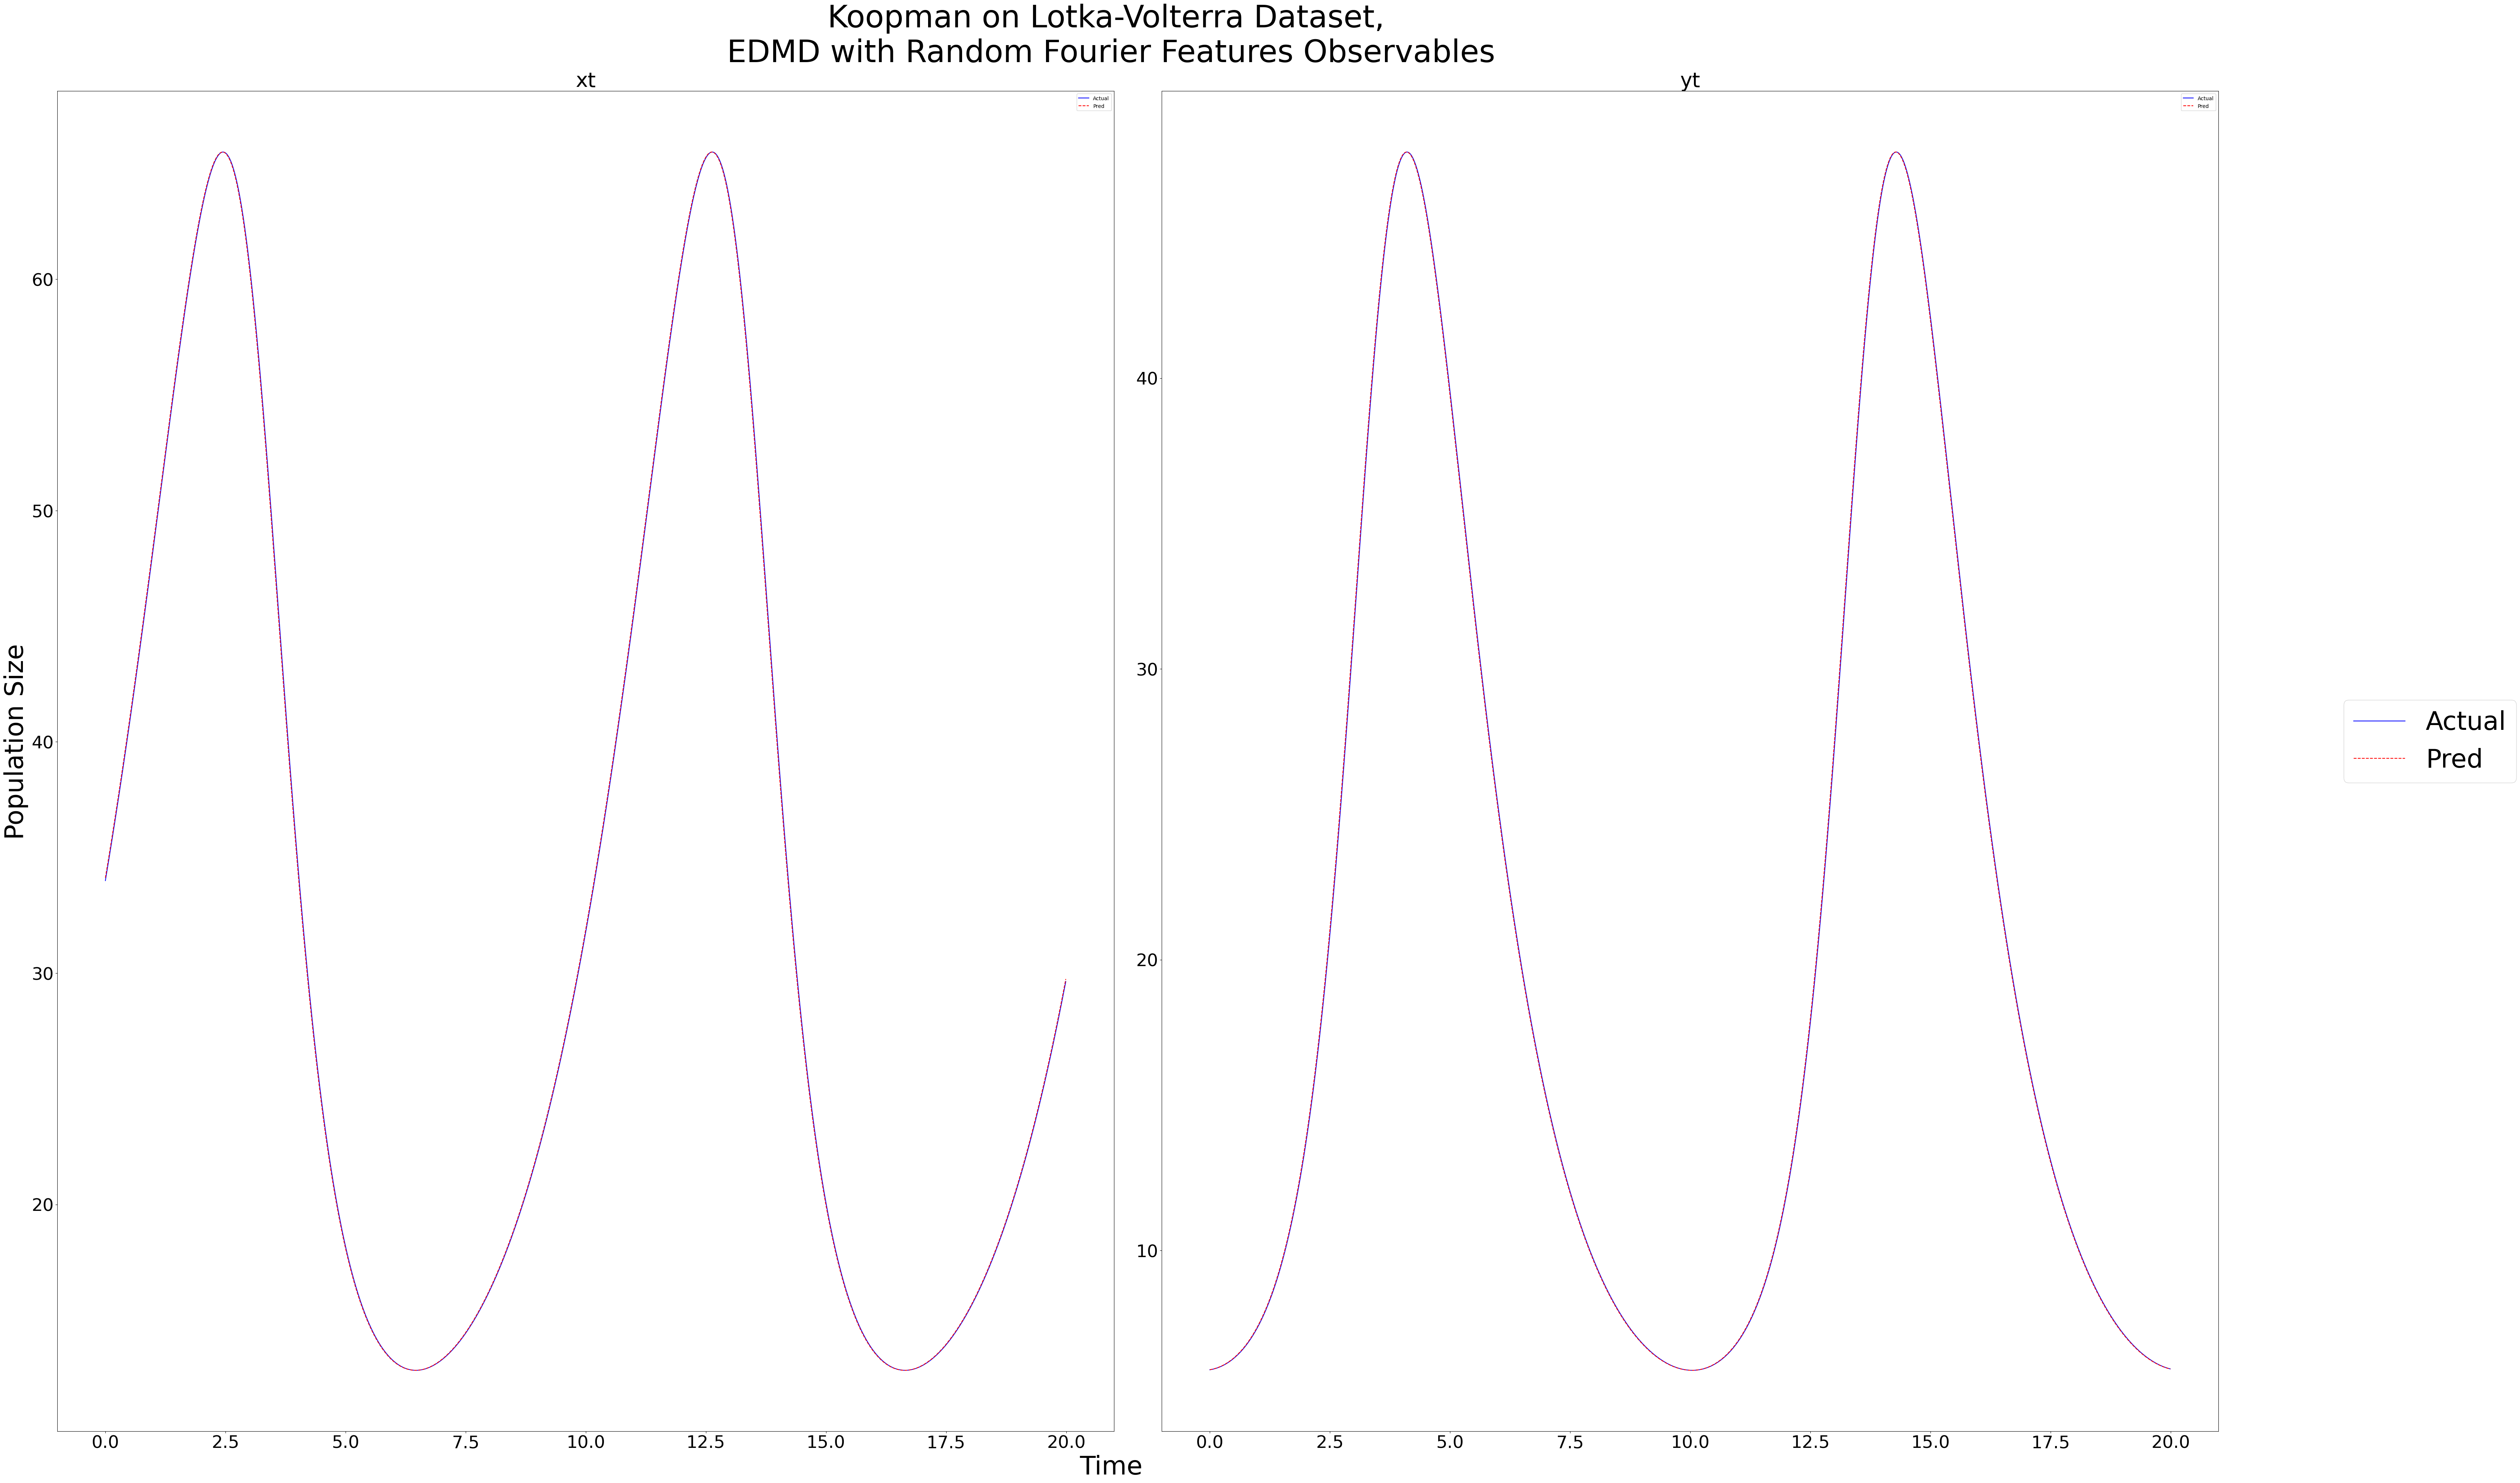

In [89]:
fig, axs = plt.subplots(1, 2,
                        figsize=(60, 40), layout = "constrained")

Xmin = min(Xkoop_test.shape[0], koopman_pred_df.shape[0])

gene_cols = glv_df.iloc[:, 1:].columns.tolist()

for col in range(koopman_pred_df.shape[1]):
  r, c = divmod(col, 5)

  colname = gene_cols[col]

  axs[col].plot(time_vec[:Xmin],
                 Xkoop_test[:Xmin, col],
                 '-',
                 color='b',
                 label='Actual')
  axs[col].plot(time_vec[:Xmin],
                 koopman_pred_df.iloc[:Xmin, :].loc[:, colname].values,
                 '--r',
                 label='Pred')
  axs[col].legend()
  axs[col].set_title(colname, fontsize = 40)
  axs[col].tick_params(axis='both', which='major', labelsize=34)
  axs[col].tick_params(axis='both', which='minor', labelsize=30)


# Plot
handles, labels = axs[col].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize= 50)

fig.supxlabel('Time', fontsize = 50)
fig.supylabel('Population Size', fontsize = 50)
suptitle_ncde = f'Koopman on Lotka-Volterra Dataset, \nEDMD with Random Fourier Features Observables'
plt.suptitle(suptitle_ncde, fontsize = 60)

plt.savefig(os.path.join(plots_glv_path, f'dmd_glv2_poly.png'))
plt.show()

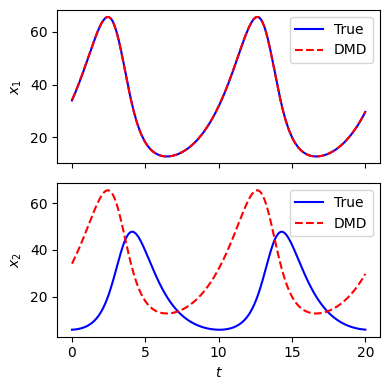

In [58]:
fig, axs = plt.subplots(2, 1, sharex=True, tight_layout=True, figsize=(4, 4))

Xmin = min(Xkoop_test.shape[0], koopman_pred_df.shape[0])

axs[0].plot(time_vec[:Xmin], Xkoop_test[:Xmin, 0], '-', color='b', label='True')
axs[0].plot(time_vec[:Xmin], koopman_pred_df.iloc[:Xmin, 0].values, '--r', label='DMD')
axs[0].set(ylabel=r'$x_1$')
axs[1].plot(time_vec[:Xmin], Xkoop_test[:Xmin, 1], '-', color='b', label='True')
axs[1].plot(time_vec[:Xmin], koopman_pred_df.iloc[:Xmin, 0].values, '--r', label='DMD')
axs[1].set(
        ylabel=r'$x_2$',
        xlabel=r'$t$')
for i in range(2):
    axs[i].legend(loc='best')

## Eigenvectors and Eigenvalues

In [59]:
koop_lv_eigenvals = np.log(np.linalg.eig(model_edmd.A)[0])/DT

print(f"koopman eigenvalues = {koop_lv_eigenvals}")

koopman eigenvalues = [-6.85395970e-03+1.1023013j  -6.85395970e-03-1.1023013j
 -8.57680073e-03+1.01099148j -8.57680073e-03-1.01099148j
 -1.01861860e-02+0.94153231j -1.01861860e-02-0.94153231j
 -1.00276980e-02+0.88095971j -1.00276980e-02-0.88095971j
 -1.26357043e-01+0.90464634j -1.26357043e-01-0.90464634j
 -9.89438805e-03+0.82827664j -9.89438805e-03-0.82827664j
 -1.10293866e-02+0.78126028j -1.10293866e-02-0.78126028j
 -1.26975026e-02+0.73723204j -1.26975026e-02-0.73723204j
 -7.13563841e-02+0.72973691j -7.13563841e-02-0.72973691j
 -1.24497006e-02+0.69608344j -1.24497006e-02-0.69608344j
 -1.13931885e-02+0.65885807j -1.13931885e-02-0.65885807j
 -4.52435135e-02+0.63010537j -4.52435135e-02-0.63010537j
 -8.62616677e-03+0.62457751j -8.62616677e-03-0.62457751j
 -4.90363653e-03+0.59689785j -4.90363653e-03-0.59689785j
 -3.59482891e-03+0.5744591j  -3.59482891e-03-0.5744591j
 -3.85992127e-03+0.55512847j -3.85992127e-03-0.55512847j
 -4.33038825e-03+0.53738077j -4.33038825e-03-0.53738077j
 -5.0483450

In [60]:
for eigval in model_edmd.continuous_lamda_array:
    print('continuous eigenvalue = ',eigval)


continuous eigenvalue =  (-0.00685395970087338+1.10230129942974j)
continuous eigenvalue =  (-0.00685395970087338-1.10230129942974j)
continuous eigenvalue =  (-0.00857680072572848+1.0109914813698915j)
continuous eigenvalue =  (-0.00857680072572848-1.0109914813698915j)
continuous eigenvalue =  (-0.01018618603980726+0.9415323072894837j)
continuous eigenvalue =  (-0.01018618603980726-0.9415323072894837j)
continuous eigenvalue =  (-0.010027698026971822+0.8809597124689716j)
continuous eigenvalue =  (-0.010027698026971822-0.8809597124689716j)
continuous eigenvalue =  (-0.1263570430425169+0.9046463350470042j)
continuous eigenvalue =  (-0.1263570430425169-0.9046463350470042j)
continuous eigenvalue =  (-0.00989438804520948+0.8282766389102169j)
continuous eigenvalue =  (-0.00989438804520948-0.8282766389102169j)
continuous eigenvalue =  (-0.011029386624553418+0.781260277992294j)
continuous eigenvalue =  (-0.011029386624553418-0.781260277992294j)
continuous eigenvalue =  (-0.012697502638786707+0.73

<AxesSubplot:>

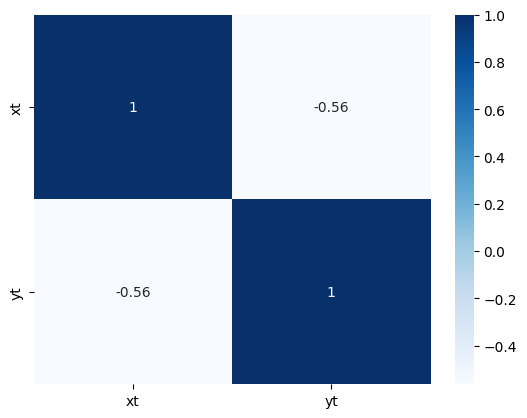

In [62]:
modes_real_df = pd.DataFrame(model_edmd.W.real)
modes_real_corr = modes_real_df.T.corr()
modes_real_corr.index = glv_df.iloc[:, 1:].columns.tolist()
modes_real_corr.columns = glv_df.iloc[:, 1:].columns.tolist()

sns.heatmap(modes_real_corr,
            cmap = 'Blues',
            annot=True, xticklabels=True, yticklabels=True)

<AxesSubplot:>

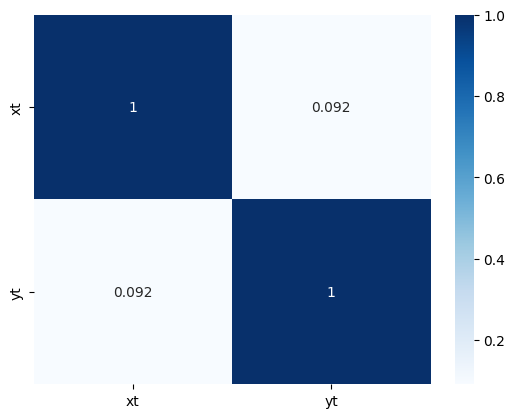

In [63]:
modes_imag_df = pd.DataFrame(model_edmd.W.imag)
modes_imag_corr = modes_imag_df.T.corr()
modes_imag_corr.index = glv_df.iloc[:, 1:].columns.tolist()
modes_imag_corr.columns = glv_df.iloc[:, 1:].columns.tolist()

sns.heatmap(modes_imag_corr,
            cmap = 'Blues',
            annot=True, xticklabels=True, yticklabels=True)

In [64]:
def manual_covariance(x):
    mean = x.mean(axis=1)
    print(x.shape[1])
    cov = np.zeros((len(x), len(x)), dtype='complex64')

    for i in range(len(mean)):
        for k in range(len(mean)):
            s = 0
            for j in range(len(x[1])):  # 5 Col
                s += np.dot((x[i,j] - mean[i]), np.conj(x[k,j] - mean[i]))
            cov[i, k] = s / ((x.shape[1]) - 1)
    return cov

202


<ipython-input-65-2f88d8f68244>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'dmd_glv_edmd_fourier_cov.png'))
<ipython-input-65-2f88d8f68244>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'dmd_glv_edmd_fourier_cov.png'))
<ipython-input-65-2f88d8f68244>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'dmd_glv_edmd_fourier_cov.png'))
<ipython-input-65-2f88d8f68244>:11: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no l

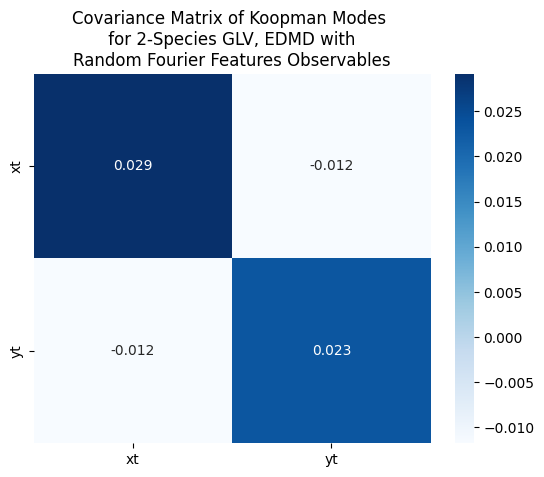

In [65]:
modes_both_df = pd.DataFrame(manual_covariance(model_edmd.W).real,
                            index = glv_df.iloc[:, 1:].columns.tolist(),
                            columns = glv_df.iloc[:, 1:].columns.tolist()
                            )

sns.heatmap(modes_both_df,
            cmap = 'Blues',
            annot=True, xticklabels=True, yticklabels=True)
plt.title("Covariance Matrix of Koopman Modes \n" +
          " for 2-Species GLV, EDMD with \nRandom Fourier Features Observables")
plt.savefig(os.path.join(plots_glv_path, 'dmd_glv_edmd_fourier_cov.png'))

## Koopman / DMD Performance Metrics

In [66]:
koopman_pooled_mse = pooled_mse(true_df = glv_df.iloc[:, 1:], pred_df = koopman_pred_df)
koopman_pooled_r2 = r2_score(y_true = glv_df.iloc[:, 1:], y_pred = koopman_pred_df)
koop_coupling = compare_coupling(pred_df = modes_real_corr, true_df = true_adjacency)

In [67]:
print(f"Pooled MSE: {koopman_pooled_mse}")
print(f"R2: {koopman_pooled_r2}")
print(f"Coupling: {koop_coupling}")

Pooled MSE: 0.01380289774877228
R2: 0.9999471385620857
Coupling: 2.000337971443826


# Bayesian Lotka-Volterra

## Helper Functions

In [68]:
# decorator with input and output types a Pytensor double float tensors
@as_op(itypes=[pt.dmatrix], otypes=[pt.dmatrix])

def pytensor_forward_model_matrix(theta):

    X0 = theta[0, :]
    r = theta[1, :]
    AX = theta[2, :]

    return odeint(func=gLV, y0=X0,
                  t=glv_df.time,
                  args=(r, AX))



def gLV(X, t, r, AX):
    return X * (r + AX)

## Specify Model

<AxesSubplot:xlabel='time'>

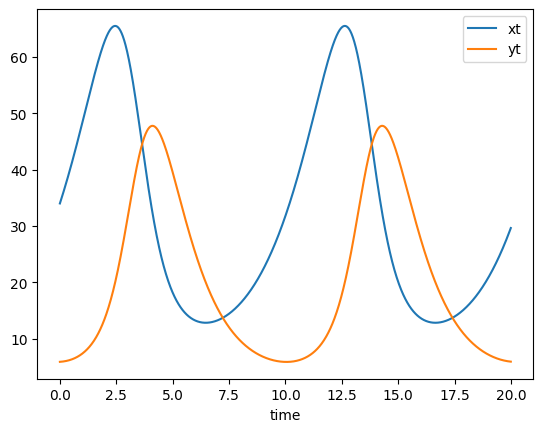

In [69]:
glv_df.plot(x = 'time')

In [70]:
glv_df.iloc[:, 1:].corr()

,xt,yt
xt,1.00000,-0.00055
yt,-0.00055,1.00000


In [71]:
# theta_glv4 = results_glv4.x  # least squares solution used to inform the priors
n = glv_df.shape[1] - 1
with pm.Model() as model:

    priors = []

    # Params for X0
    X0 = pm.Uniform("X0",
                    lower=0,
                    upper=50,
                    shape=n,
                    initval=glv_df.iloc[1, 1:].values)
    priors.append(X0)

    # Params for r
    r = pm.Normal("r",
                  mu=0,
                  sigma=2,
                  shape=n)
    priors.append(r)


    # Params for A
    A = pm.Normal("A",
                  mu=0,
                  sigma=2,
                  shape=(n, n),
                  initval=glv_df.iloc[:, 1:].corr().values)

    AX = pm.Deterministic(name = "AX", var = pm.math.dot(A, X0))
    priors.append(AX)

    # # Params for linear term B
    # B = pm.Normal("B",
    #               mu=0,
    #               sigma=10,
    #               shape=n)
    # priors.append(B)

    # Priors
    sigma = pm.HalfNormal("sigma", 3)

    # Ode solution function for Lotka-Volterra
    ode_solution = pytensor_forward_model_matrix(
        pm.math.stack(priors)
    )

    # Likelihood
    pm.Normal("Y_obs",
              mu=ode_solution,
              sigma=sigma,
              observed=glv_df.iloc[:, 1:].values)

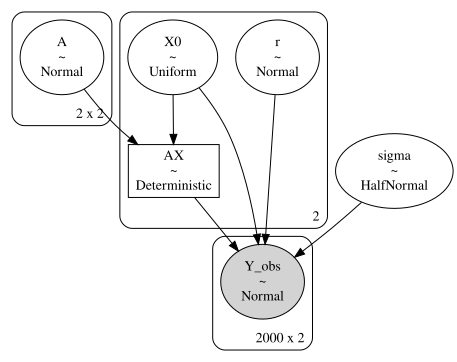

In [72]:
pm.model_to_graphviz(model=model)


## Sampling

In [73]:
# Variable list to give to the sample step parameter
vars_list = list(model.values_to_rvs.keys())[:-1]

# Specify the sampler
sampler = "Slice Sampler"
tune = draws = 1000

# Inference!
with model:
    trace_slice = pm.sample(step=[pm.Metropolis(vars_list)],
                            tune = tune,
                            draws = draws,
                            progressbar = True)

trace = trace_slice
az_trace = az.summary(trace)
az_trace

/usr/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

<ipython-input-68-c222342b61f4>:17: RuntimeWarning: overflow encountered in multiply
  return X * (r + AX)
/usr/local/lib/python3.11/dist-packages/scipy/integrate/_odepack_py.py:248: ODEintWarning: Illegal input detected (internal error). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
/usr/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
<ipython-input-68-c222342b61f4>:17: RuntimeWarning: overflow encountered in multiply
  return X * (r + AX)
/usr/local/lib/python3.11/dist-packages/scipy/integrate/_odepack_py.py:248: ODEintWarning: Excess accuracy requested (tolerances too small). Run with full_output = 1 to get quantitative information.
  warnings.warn(warning_msg, ODEintWarning)
/usr/local/lib/python3.11/dist-packages/scipy/integrate/_odepack_py.py:248: O

/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/usr/local/lib/python3.11/dist-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"A[0, 0]",1.000,0.0,1.000,1.000,0.0,NaN,4000.0,4000.0,NaN
"A[0, 1]",-0.001,0.0,-0.001,-0.001,0.0,0.0,4000.0,4000.0,NaN
"A[1, 0]",-0.001,0.0,-0.001,-0.001,0.0,0.0,4000.0,4000.0,NaN
"A[1, 1]",1.000,0.0,1.000,1.000,0.0,NaN,4000.0,4000.0,NaN
AX[0],34.122,0.0,34.122,34.122,0.0,0.0,4000.0,4000.0,NaN
AX[1],5.884,0.0,5.884,5.884,0.0,0.0,4000.0,4000.0,NaN
X0[0],34.125,0.0,34.125,34.125,0.0,NaN,4000.0,4000.0,NaN
X0[1],5.903,0.0,5.903,5.903,0.0,NaN,4000.0,4000.0,NaN
r[0],0.000,0.0,0.000,0.000,0.0,NaN,4000.0,4000.0,NaN
r[1],0.000,0.0,0.000,0.000,0.0,NaN,4000.0,4000.0,NaN


In [ ]:
with pm.Model() as model_lv:
    priors = []

    # Params for X0
    X0 = pm.Uniform('X0',
                    lower=0,
                    upper=50,
                    shape=n,
                    initval=glv_df.iloc[1, 1:].values)
    priors.append(X0)

    # Params for r
    r = pm.Normal('r',
                  mu=0,
                  sigma=2,
                  shape=n)
    priors.append(r)


    # Params for A
    A = pm.Normal('A',
                  mu=0,
                  sigma=2,
                  shape=(n, n),
                  initval=glv_df.iloc[:, 1:].corr().values)

    AX = pm.Deterministic(name = 'AX', var = pm.math.dot(A, X0))
    priors.append(AX)

    sim = pm.Simulator('sim', gLV, params=(r, AX), epsilon=10, observed=glv_df.iloc[:, 1:].values)

    trace_lv = pm.sample_smc()
    idata_lv = az.from_pymc3(trace_lv)

Output()

KeyboardInterrupt: 

## Evaluate Performance

## Get Posterior Params

In [74]:
A_mh = az_trace.loc[az_trace['mean'].index.str.startswith('A['), 'mean'].values.reshape((n, n))
X0_mh = az_trace.loc[az_trace['mean'].index.str.startswith('X0'), 'mean'].values
r_mh = az_trace.loc[az_trace['mean'].index.str.startswith('r'), 'mean'].values
B_mh = az_trace.loc[az_trace['mean'].index.str.startswith('B'), 'mean'].values

A_mh_df = pd.DataFrame(A_mh,
                       columns = glv_df.columns[1:],
                       index = glv_df.columns[1:])
A_mh_df

,xt,yt
xt,1.000,-0.001
yt,-0.001,1.000


In [75]:
traj_mh = odeint(func=gLV, y0=X0_mh,
                  t=glv_df.time,
                  args=(r_mh, A_mh @ X0_mh))

bayesian_glv_pred_df = pd.DataFrame(traj_mh, columns = glv_df.columns[1:])
bayesian_glv_pred_df

/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,xt,yt
0,3.412500e+01,5.903000e+00
1,4.800097e+01,6.259808e+00
2,6.751921e+01,6.638182e+00
3,9.497400e+01,7.039428e+00
4,1.335925e+02,7.464927e+00
...,...,...
1995,1.402498e+297,4.169004e+51
1996,1.972784e+297,4.421000e+51
1997,2.774961e+297,4.688228e+51
1998,3.903321e+297,4.971609e+51


## Recreate Trajectories & Compare (Plot Predictions)

<ipython-input-76-67cc2088e734>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'bglv_glv2_traj_normal.png'))
<ipython-input-76-67cc2088e734>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'bglv_glv2_traj_normal.png'))
<ipython-input-76-67cc2088e734>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'bglv_glv2_traj_normal.png'))
<ipython-input-76-67cc2088e734>:37: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer sup

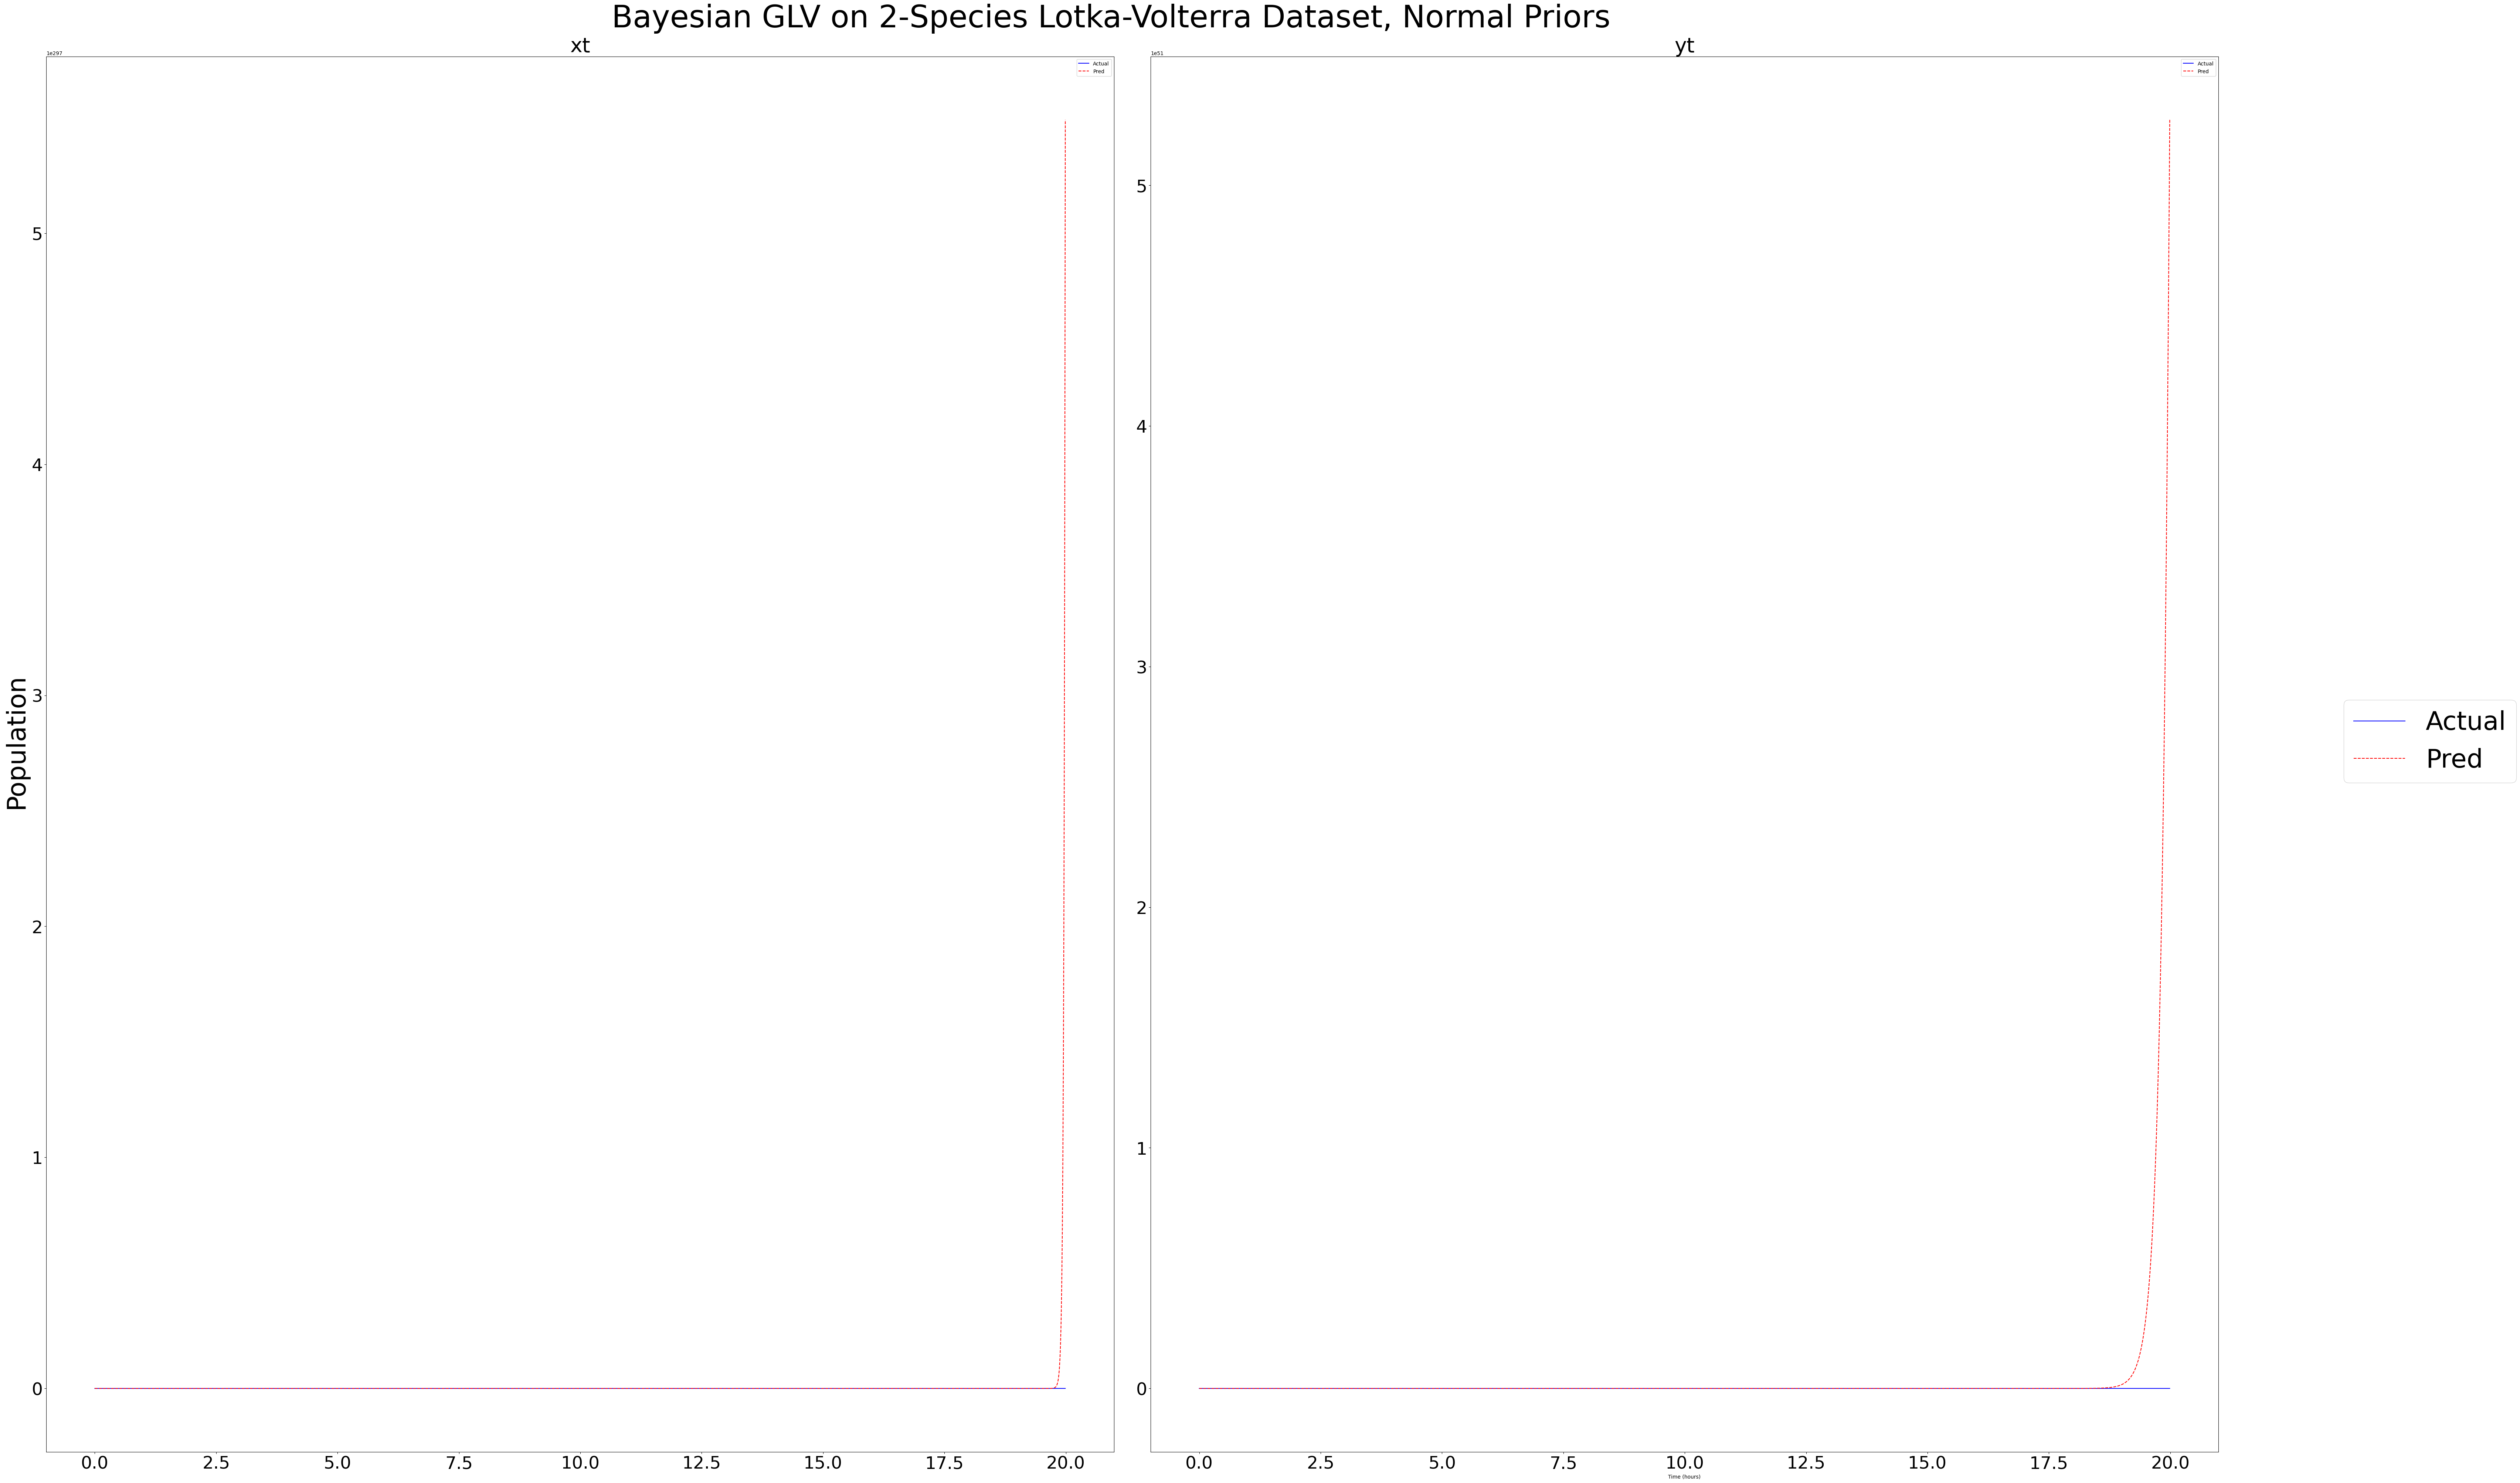

In [76]:
fig, axs = plt.subplots(1, 2,
                        figsize=(60, 40), layout = "constrained")

gene_cols = glv_df.iloc[:, 1:].columns.tolist()
time_vec_mh = glv_df['time'].values

for col in range(bayesian_glv_pred_df.shape[1]):
  colname = gene_cols[col]

  glv_df.loc[:, colname].values

  axs[col].plot(time_vec_mh,
                 glv_df.loc[:, colname].values,
                 '-',
                 color='b',
                 label='Actual')
  axs[col].plot(time_vec_mh,
                 bayesian_glv_pred_df.loc[:, colname].values,
                 '--r',
                 label='Pred')
  axs[col].legend()
  axs[col].set_title(colname, fontsize = 40)
  axs[col].tick_params(axis='both', which='major', labelsize=34)
  axs[col].tick_params(axis='both', which='minor', labelsize=30)


# Plot
handles, labels = axs[col].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), loc='center left', fontsize= 50)


# Plot
plt.xlabel('Time (hours)')
fig.supylabel('Population', fontsize = 50)
suptitle_bglv = 'Bayesian GLV on 2-Species Lotka-Volterra Dataset, Normal Priors'
plt.suptitle(suptitle_bglv, fontsize = 60)
plt.savefig(os.path.join(plots_glv_path, 'bglv_glv2_traj_normal.png'))
plt.show()

## Interaction Matrix Posterior Heatmap

<ipython-input-77-b0d8d32adcd8>:4: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "bayes_glv_covariance_2glv.png"))
<ipython-input-77-b0d8d32adcd8>:4: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "bayes_glv_covariance_2glv.png"))
<ipython-input-77-b0d8d32adcd8>:4: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, "bayes_glv_covariance_2glv.png"))
<ipython-input-77-b0d8d32adcd8>:4: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no lo

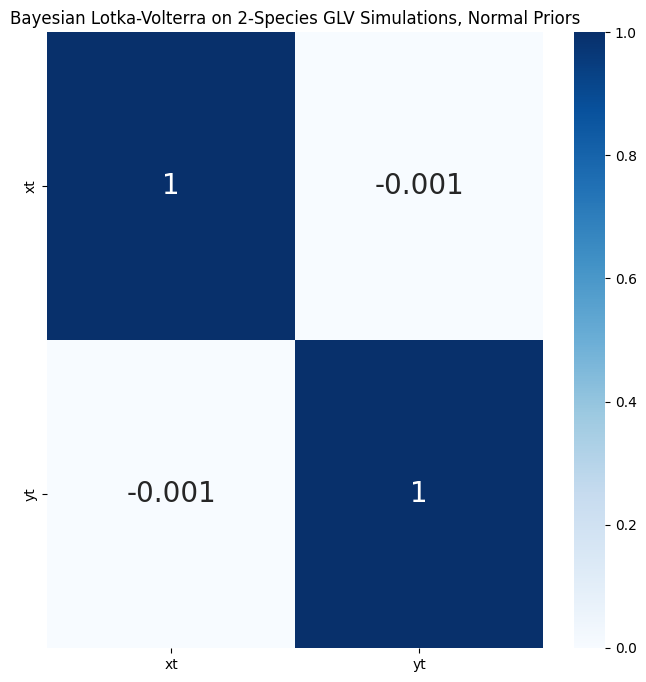

In [77]:

plt.figure(figsize=(8,8))
sns.heatmap(A_mh_df, cmap = 'Blues', annot=True, xticklabels=True, yticklabels=True, annot_kws={"fontsize":20})
plt.title('Bayesian Lotka-Volterra on 2-Species GLV Simulations, Normal Priors')
plt.savefig(os.path.join(plots_glv_path, "bayes_glv_covariance_2glv.png"))


### Interaction Matrix Prior - Gene Covariance Matrix Heatmap

To benchmark how much $A$ changes in the posterior

<AxesSubplot:>

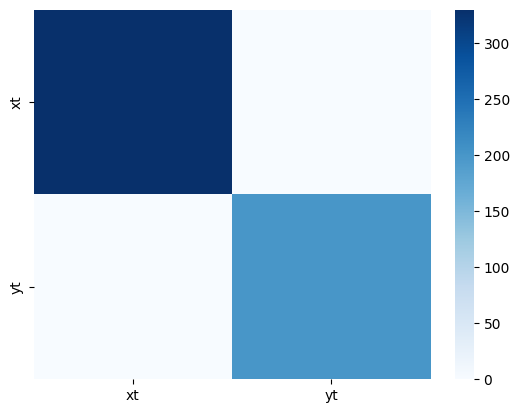

In [78]:

sns.heatmap(glv_df.iloc[:, 1:].cov(),
            cmap = 'Blues',
            xticklabels=True,
            yticklabels=True)


## Performance Metrics

In [79]:
bayes_glv_pooled_mse = pooled_mse(true_df = glv_df.iloc[:, 1:], pred_df = bayesian_glv_pred_df)

/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [80]:
notnull_idx = bayesian_glv_pred_df.index[bayesian_glv_pred_df.isnull().sum(axis=1) == 0]

In [81]:
bayesian_glv_pred_df.iloc[notnull_idx]

/usr/local/lib/python3.11/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,xt,yt
0,3.412500e+01,5.903000e+00
1,4.800097e+01,6.259808e+00
2,6.751921e+01,6.638182e+00
3,9.497400e+01,7.039428e+00
4,1.335925e+02,7.464927e+00
...,...,...
1995,1.402498e+297,4.169004e+51
1996,1.972784e+297,4.421000e+51
1997,2.774961e+297,4.688228e+51
1998,3.903321e+297,4.971609e+51


In [82]:
bayes_glv_r2 = r2_score(y_true = glv_df.iloc[notnull_idx, 1:] // 10000, y_pred = bayesian_glv_pred_df.iloc[notnull_idx] // 10000)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_regression.py:927: RuntimeWarning: overflow encountered in square
  numerator = (weight * (y_true - y_pred) ** 2).sum(axis=0, dtype=np.float64)
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [84]:
glv_coupling = compare_coupling(true_df = true_adjacency, pred_df = A_mh_df)

### Summary of Performance Metrics

In [85]:
print(f"Pooled MSE: {bayes_glv_pooled_mse}")
print(f"R2: {bayes_glv_r2}")
print(f"Coupling: {glv_coupling}")

Pooled MSE: inf
R2: 0.0
Coupling: 2.000337971443826


# Summary Results Across Methods

<ipython-input-207-1e7565ae38ac>:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "orientation" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'glv_all.png'))
<ipython-input-207-1e7565ae38ac>:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "facecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'glv_all.png'))
<ipython-input-207-1e7565ae38ac>:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "edgecolor" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(os.path.join(plots_glv_path, 'glv_all.png'))
<ipython-input-207-1e7565ae38ac>:52: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "bbox_inches_restore" which is no longer supported as of 3.3 and will become an er

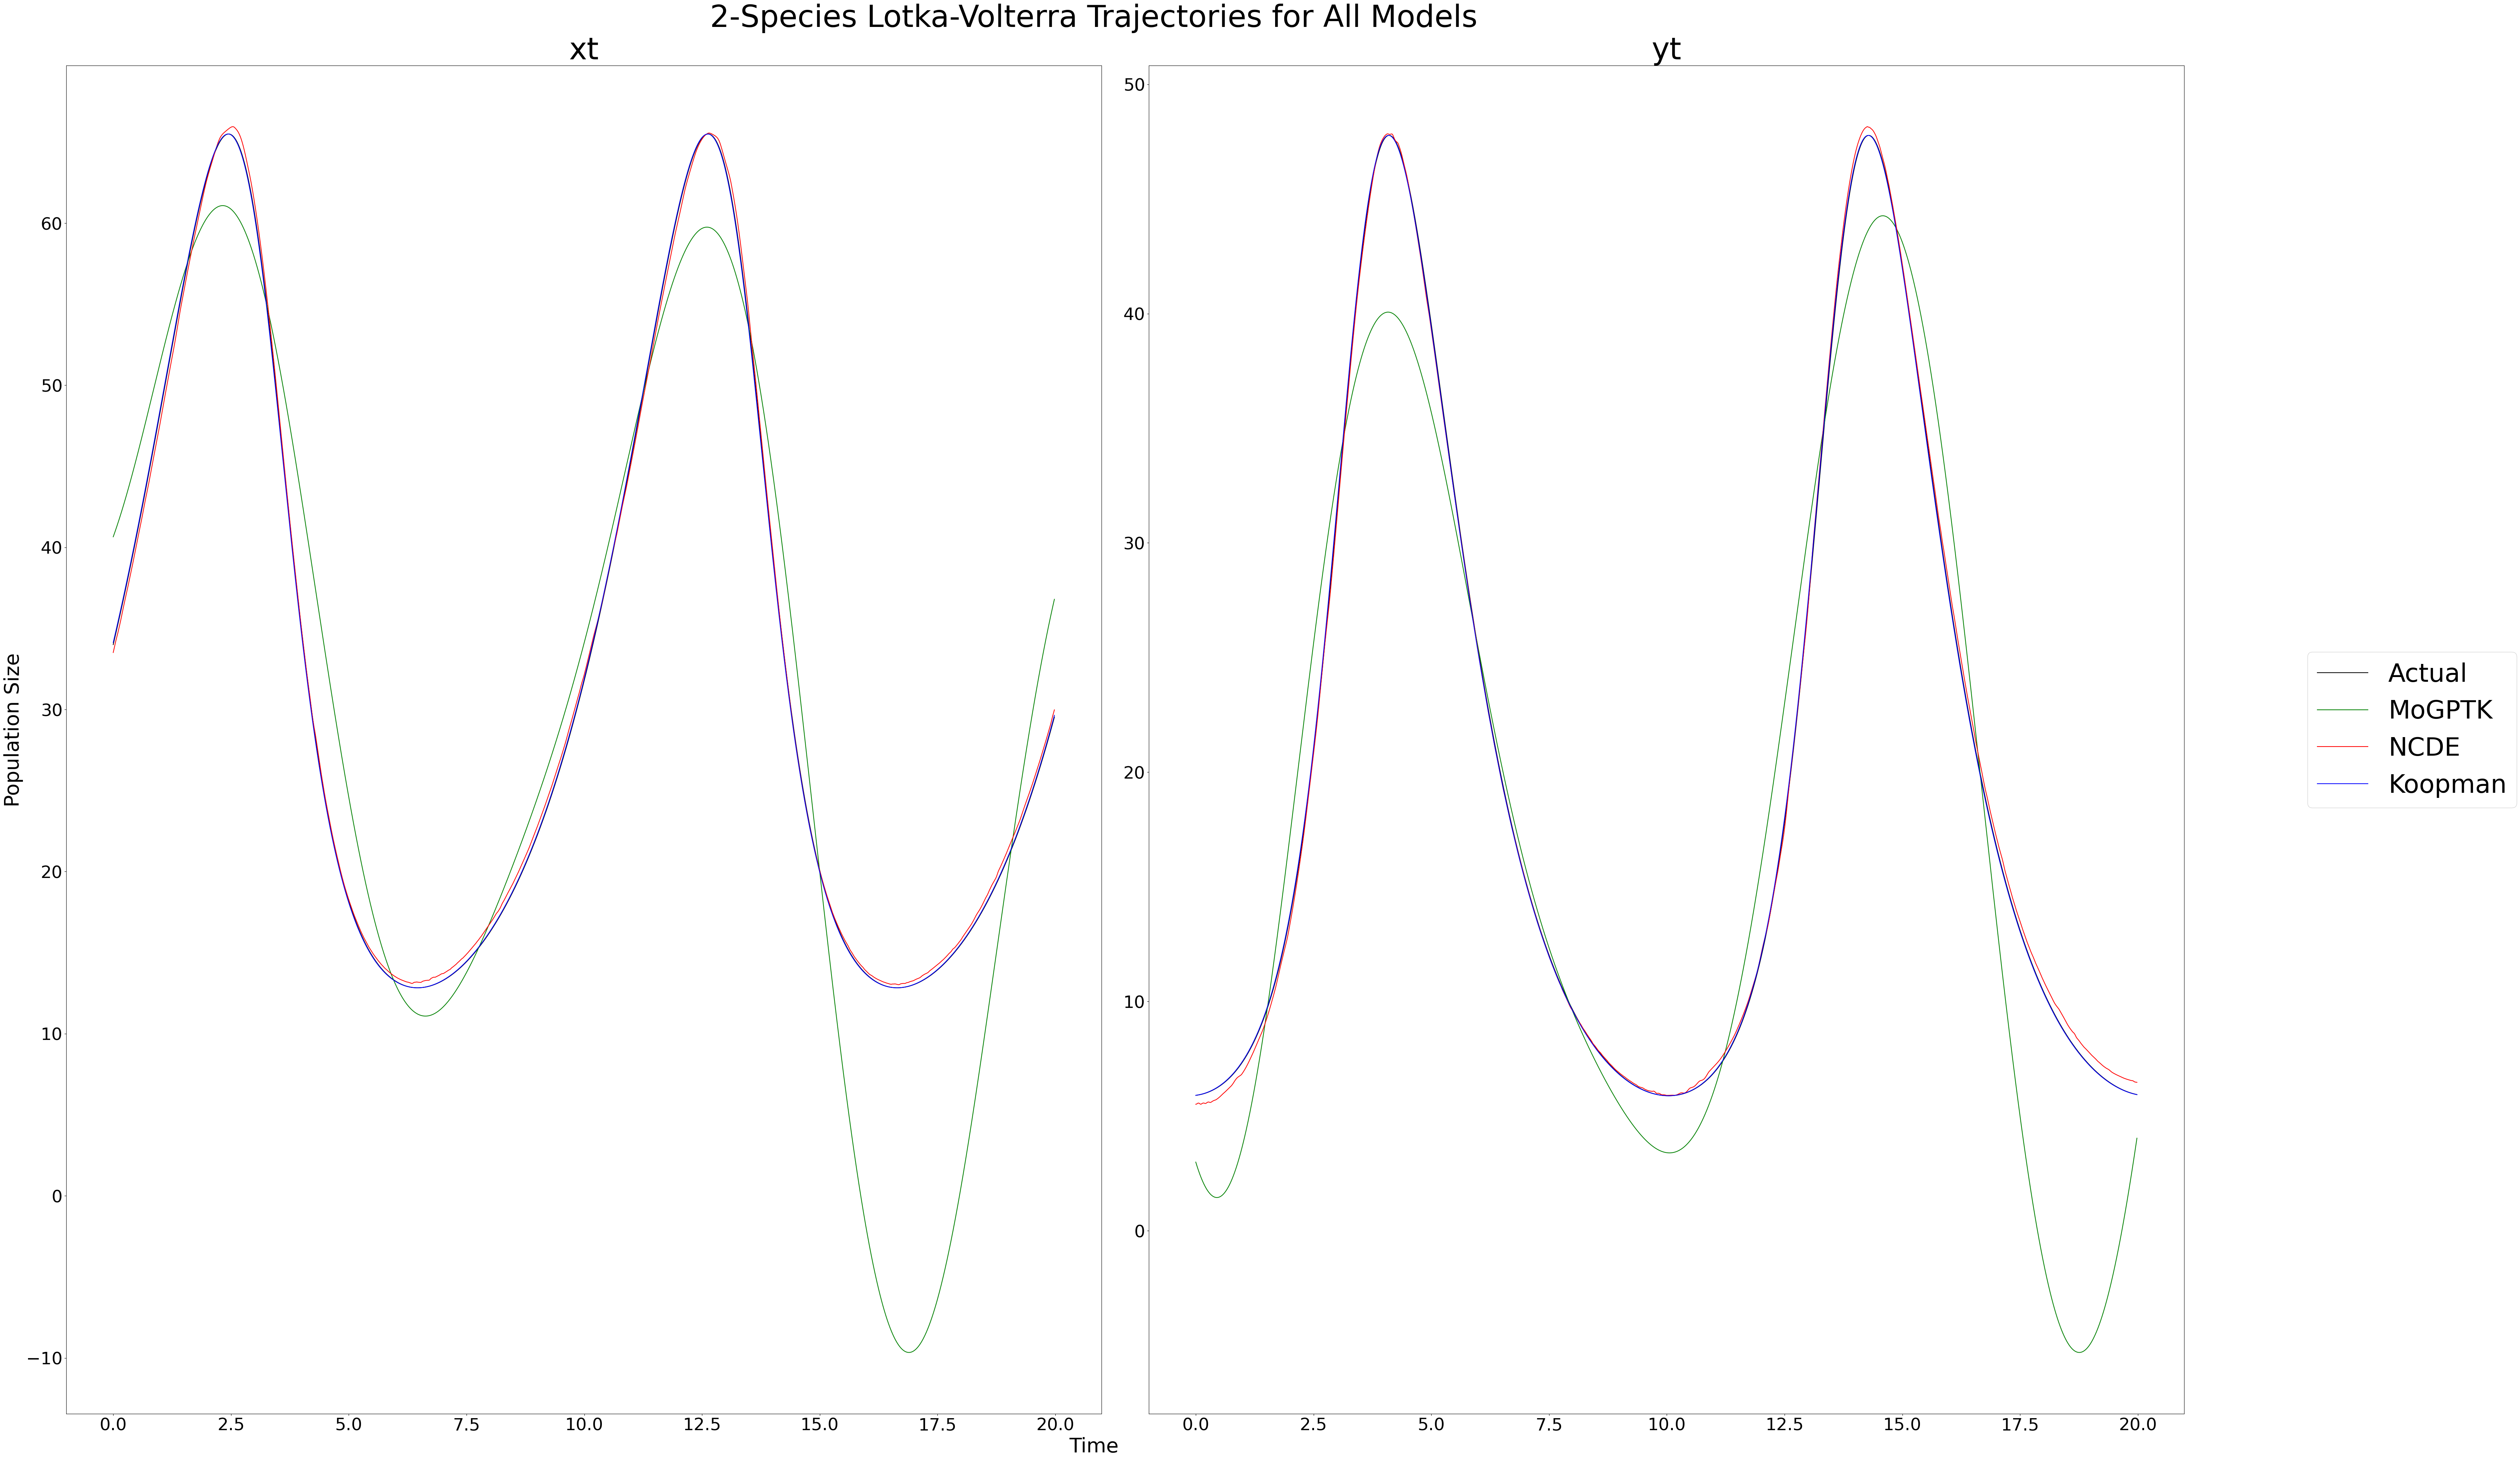

In [ ]:
fig, axs = plt.subplots(1, 2, figsize = (60, 40), layout = "constrained")

gene_cols = glv_df.iloc[:, 1:].columns.tolist()

for col in range(ncde_pred_df.shape[1]):

  colname = gene_cols[col]

  axs[col].plot(time_vec[:-1],
                 glv_df.iloc[:-1, :].loc[:, colname].values,
                 '-',
                 color='0',
                 label='Actual')

  axs[col].plot(time_vec[:-1],
                 mogptk_preds_df.iloc[:-1, :].loc[:, colname].values,
                 'g',
                 label='MoGPTK')

  axs[col].plot(time_vec[:-1],
                ncde_pred_df.loc[:, colname].values,
                label = 'NCDE',
                color='r')

  axs[col].plot(time_vec[:-1],
                 koopman_pred_df.iloc[:-1, :].loc[:, colname].values,
                 label='Koopman',
                 color='b')

  # axs[r, c].plot(time_vec[:-1],
  #                bayesian_glv_pred_df.iloc[:-1, :].loc[:, colname].values,
  #                label='Bayes GLV',
  #                color='c')
  axs[col].set_title(colname, fontsize = 60)


fig.supxlabel('Time', fontsize = 40)
fig.supylabel('Population Size', fontsize = 40)

for a in axs.flatten():
    a.tick_params(axis='both', which='major', labelsize=34)
    a.tick_params(axis='both', which='minor', labelsize=30)

# Get handles and labels from one of the subplots
handles, labels = axs[col].get_legend_handles_labels()

fig.legend(handles, labels, bbox_to_anchor=(1.05, 0.5), ncol = 1,
           loc='center left', fontsize = 50)

suptitle_all = '2-Species Lotka-Volterra Trajectories for All Models'
plt.suptitle(suptitle_all, fontsize = 60)
plt.savefig(os.path.join(plots_glv_path, 'glv_all.png'))
plt.show()

# Appendix

## NCDE Trial Runs

### NCDE Run: 4/13/2025 6:35 PM, 500 steps

Finished control with CubicInterpolation(
  ts=f32[166], coeffs=[f32[165,31], f32[165,31], f32[165,31], f32[165,31]]
)
ts[0] shape: ()
y0 shape: (16,)
y_true: (32, 166, 30); y_pred: (32, 166, 30).
Step: 0, Loss: 3595.550537109375, Accuracy: 3595.550537109375, Computation time: 21.925617933273315
Step: 1, Loss: 3555.825927734375, Accuracy: 3555.825927734375, Computation time: 1.09849214553833
Step: 2, Loss: 3507.551025390625, Accuracy: 3507.551025390625, Computation time: 1.6345157623291016
Step: 3, Loss: 3487.687255859375, Accuracy: 3487.687255859375, Computation time: 0.76163649559021
Step: 4, Loss: 3472.209228515625, Accuracy: 3472.209228515625, Computation time: 0.6960725784301758
Step: 5, Loss: 3440.94921875, Accuracy: 3440.94921875, Computation time: 0.8357787132263184
Step: 6, Loss: 3413.404296875, Accuracy: 3413.404296875, Computation time: 0.8866899013519287
Step: 7, Loss: 3391.3505859375, Accuracy: 3391.3505859375, Computation time: 1.196861982345581
Step: 8, Loss: 3376.815917

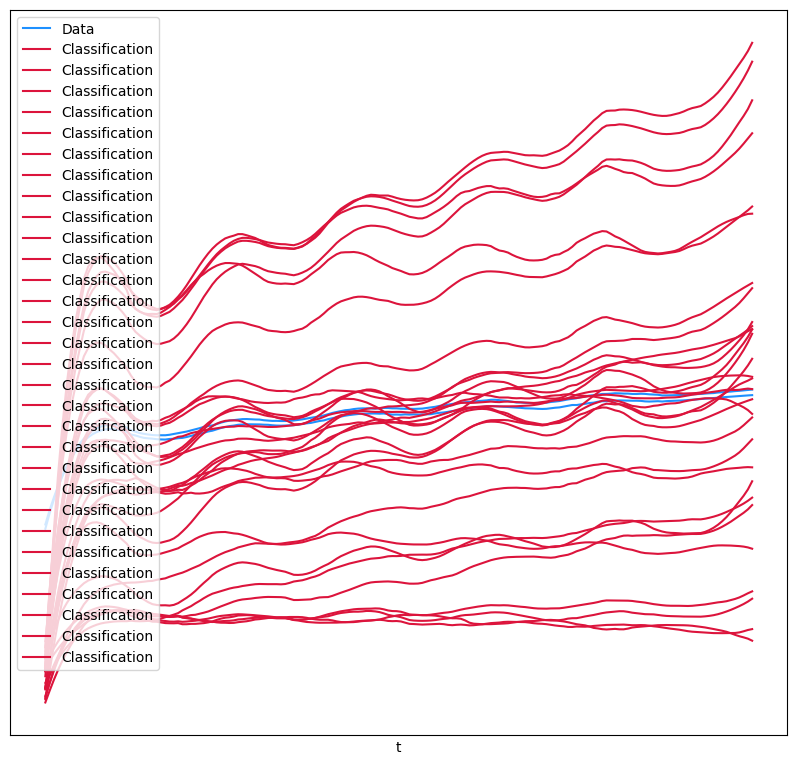

In [ ]:
# Training loop like normal.
### Model Instantiation ###
# NeuralCDEV2 is a class that takes in an (N, T - 1, G) tensor and the network architecture params.
# When instantiated (as done below)
model_sim = NeuralCDE(data_size = X_waveforms.shape[-1],
                      hidden_size = HIDDEN_SIZE,
                      width_size = WIDTH_SIZE,
                      output_size = OUTPUT_SIZE,
                      depth = DEPTH,
                      key = model_key)

### FUNCTIONS ###
def ncde_predict(model, ti, coeff_i, evolving_out = False):
    if evolving_out:
        def model_evolving(ts, coeffs):
            return model(ts, coeffs, evolving_out = True)
        return jax.vmap(model_evolving)(ti, coeff_i)
    else:
        return jax.vmap(model)(ti, coeff_i)

def compute_mse(y_true, y_pred, epsilon=1e-15):
    """
    MSE Loss for forecasting with real numbers
    """
    # if y_true.ndim == 3:
    #     y_true = y_true[:, 0, :]

    # Ensure predictions are clipped to avoid log(0)
    # y_pred = jnp.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate the categorical cross-entropy
    # loss = jnp.mean(optax.l2_loss(y_pred, y_true))
    loss = jnp.mean((y_true - y_pred)**2, axis=1)

    # Return the mean loss over all samples
    return jnp.mean(loss)

@eqx.filter_jit
def loss(model, ti, y_true, coeff_i, evolving_out = False):
    pred = ncde_predict(model, ti, coeff_i, evolving_out = evolving_out)

    print(f"y_true: {y_true.shape}; y_pred: {pred.shape}.")

    # MSE
    mse_val = compute_mse(y_true = y_true, y_pred = pred)

    # mse_val = jnp.mean(mse_val)

    return mse_val, mse_val

# has_aux true will return two values: output to be differentiated and its gradient
grad_loss = eqx.filter_value_and_grad(loss, has_aux=True)

@eqx.filter_jit
def make_step(model, data_i, opt_state):
    ti, label_i, label_all_i, *coeff_i = data_i

    (mse_val, _), grads = grad_loss(model, ti, label_all_i, coeff_i, evolving_out = True)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return mse_val, model, opt_state

# Data Processing Functions
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size


### EXECUTION ###
# Optional section
optim = optax.adam(1e-4)
opt_state = optim.init(eqx.filter(model_sim, eqx.is_inexact_array))
for step, data_i in zip(
    range(steps), dataloader((t_mat2d, y_waveforms, y_waveforms_evol) + coeffs, BATCH_SIZE, key=loader_key)
):
    start = time.time()
    mse_val, model_sim, opt_state = make_step(model_sim, data_i, opt_state)
    end = time.time()
    print(
        f"Step: {step}, Loss: {mse_val}, Accuracy: {mse_val}, Computation time: "
        f"{end - start}"
    )

# ts, coeffs, labels, _ = get_data(dataset_size, add_noise, key=test_data_key)
(mse_val, _) = loss(model = model_sim,
                    ti = t_mat2d,
                    y_true = y_waveforms,
                    coeff_i = coeffs)
print(f"Test loss: {mse_val}, Test Accuracy: {mse_val}")

# Plot results : Data Preparation for Plotting
sample_ts = t_mat2d[-1] # gets the last waveform in the dataset [size: (N_TIMEPOINTS - 1,)]
# coeffs is a list of four tensors for each cubic spliene coefficient,
# so we get, for each coefficient tensor, the last row which is the coefficients of the last tensor
sample_coeffs = tuple(c[-1] for c in coeffs)
# Get predictions for that waveform
pred = model_sim(sample_ts, sample_coeffs, evolving_out=True)
# This interpolates data for the coefficients
interp = diffrax.CubicInterpolation(sample_ts, sample_coeffs)
# Evaluates sample time series for the actual values
values = jax.vmap(interp.evaluate)(sample_ts)

# Plot 1
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(sample_ts, values[:, 1], c="dodgerblue")
ax1.plot(sample_ts, values[:, 2], c="dodgerblue", label="Data")
ax1.plot(sample_ts, pred, c="crimson", label="Classification")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xlabel("t")
ax1.legend()

# Plot 2
# ax2 = fig.add_subplot(1, 2, 2, projection="3d")
# ax2.plot(values[:, 1], values[:, 2], c="dodgerblue", label="Data")
# ax2.plot(values[:, 1], values[:, 2], pred[:, 1], c="crimson", label="Classification")
# ax2.set_xticks([])
# ax2.set_yticks([])
# ax2.set_zticks([])
# ax2.set_xlabel("x")
# ax2.set_ylabel("y")
# ax2.set_zlabel("Classification")
plt.tight_layout()
plt.savefig("neural_cde.png")
plt.show()

### NCDE Run: 4/13/2025 6:25PM, 200 steps

Finished control with CubicInterpolation(
  ts=f32[166], coeffs=[f32[165,31], f32[165,31], f32[165,31], f32[165,31]]
)
ts[0] shape: ()
y0 shape: (16,)
y_true: (32, 166, 30); y_pred: (32, 166, 30).
Step: 0, Loss: 3595.26220703125, Accuracy: 3595.26220703125, Computation time: 26.537452697753906
Step: 1, Loss: 3555.12841796875, Accuracy: 3555.12841796875, Computation time: 0.9068377017974854
Step: 2, Loss: 3507.05810546875, Accuracy: 3507.05810546875, Computation time: 0.8603711128234863
Step: 3, Loss: 3488.76220703125, Accuracy: 3488.76220703125, Computation time: 0.7739553451538086
Step: 4, Loss: 3471.976318359375, Accuracy: 3471.976318359375, Computation time: 0.7465741634368896
Step: 5, Loss: 3441.75390625, Accuracy: 3441.75390625, Computation time: 0.8720881938934326
Step: 6, Loss: 3413.742919921875, Accuracy: 3413.742919921875, Computation time: 1.4321730136871338
Step: 7, Loss: 3391.753662109375, Accuracy: 3391.753662109375, Computation time: 2.754321813583374
Step: 8, Loss: 3376.

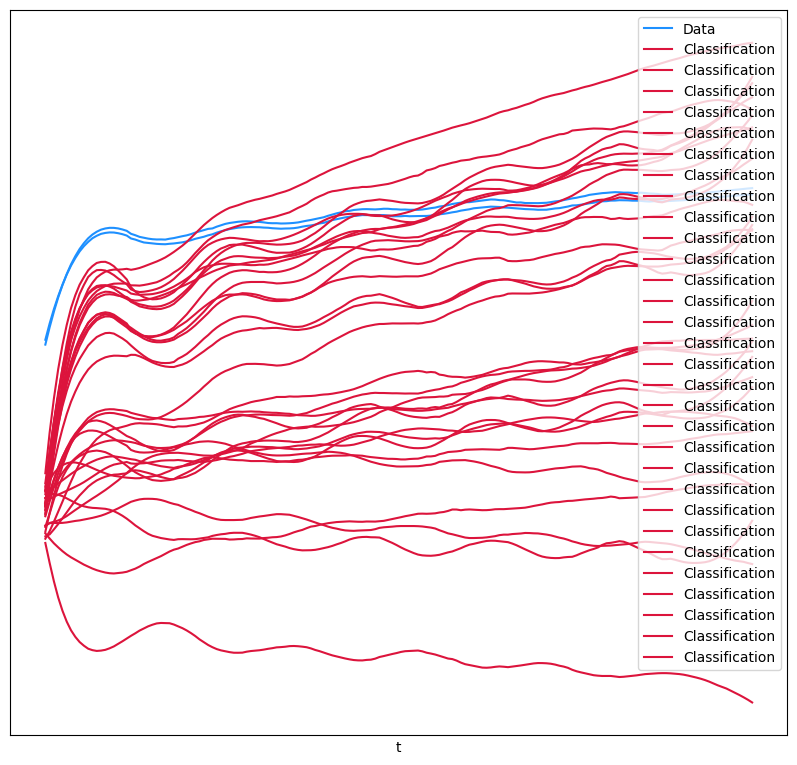

In [ ]:
# Training loop like normal.
### Model Instantiation ###
# NeuralCDEV2 is a class that takes in an (N, T - 1, G) tensor and the network architecture params.
# When instantiated (as done below)
model_sim = NeuralCDE(data_size = X_waveforms.shape[-1],
                      hidden_size = HIDDEN_SIZE,
                      width_size = WIDTH_SIZE,
                      output_size = OUTPUT_SIZE,
                      depth = DEPTH,
                      key = model_key)

### FUNCTIONS ###
def ncde_predict(model, ti, coeff_i, evolving_out = False):
    if evolving_out:
        def model_evolving(ts, coeffs):
            return model(ts, coeffs, evolving_out = True)
        return jax.vmap(model_evolving)(ti, coeff_i)
    else:
        return jax.vmap(model)(ti, coeff_i)

def compute_mse(y_true, y_pred, epsilon=1e-15):
    """
    MSE Loss for forecasting with real numbers
    """
    # if y_true.ndim == 3:
    #     y_true = y_true[:, 0, :]

    # Ensure predictions are clipped to avoid log(0)
    # y_pred = jnp.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate the categorical cross-entropy
    # loss = jnp.mean(optax.l2_loss(y_pred, y_true))
    loss = jnp.mean((y_true - y_pred)**2, axis=1)

    # Return the mean loss over all samples
    return jnp.mean(loss)

@eqx.filter_jit
def loss(model, ti, y_true, coeff_i, evolving_out = False):
    pred = ncde_predict(model, ti, coeff_i, evolving_out = evolving_out)

    print(f"y_true: {y_true.shape}; y_pred: {pred.shape}.")

    # MSE
    mse_val = compute_mse(y_true = y_true, y_pred = pred)

    # mse_val = jnp.mean(mse_val)

    return mse_val, mse_val

# has_aux true will return two values: output to be differentiated and its gradient
grad_loss = eqx.filter_value_and_grad(loss, has_aux=True)

@eqx.filter_jit
def make_step(model, data_i, opt_state):
    ti, label_i, label_all_i, *coeff_i = data_i

    (mse_val, _), grads = grad_loss(model, ti, label_all_i, coeff_i, evolving_out = True)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return mse_val, model, opt_state

# Data Processing Functions
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size


### EXECUTION ###
# Optional section
optim = optax.adam(1e-4)
opt_state = optim.init(eqx.filter(model_sim, eqx.is_inexact_array))
for step, data_i in zip(
    range(steps), dataloader((t_mat2d, y_waveforms, y_waveforms_evol) + coeffs, BATCH_SIZE, key=loader_key)
):
    start = time.time()
    mse_val, model_sim, opt_state = make_step(model_sim, data_i, opt_state)
    end = time.time()
    print(
        f"Step: {step}, Loss: {mse_val}, Accuracy: {mse_val}, Computation time: "
        f"{end - start}"
    )

# ts, coeffs, labels, _ = get_data(dataset_size, add_noise, key=test_data_key)
(mse_val, _) = loss(model = model_sim,
                    ti = t_mat2d,
                    y_true = y_waveforms,
                    coeff_i = coeffs)
print(f"Test loss: {mse_val}, Test Accuracy: {mse_val}")

# Plot results : Data Preparation for Plotting
sample_ts = t_mat2d[-1] # gets the last waveform in the dataset [size: (N_TIMEPOINTS - 1,)]
# coeffs is a list of four tensors for each cubic spliene coefficient,
# so we get, for each coefficient tensor, the last row which is the coefficients of the last tensor
sample_coeffs = tuple(c[-1] for c in coeffs)
# Get predictions for that waveform
pred = model_sim(sample_ts, sample_coeffs, evolving_out=True)
# This interpolates data for the coefficients
interp = diffrax.CubicInterpolation(sample_ts, sample_coeffs)
# Evaluates sample time series for the actual values
values = jax.vmap(interp.evaluate)(sample_ts)

# Plot 1
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(sample_ts, values[:, 1], c="dodgerblue")
ax1.plot(sample_ts, values[:, 2], c="dodgerblue", label="Data")
ax1.plot(sample_ts, pred, c="crimson", label="Classification")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xlabel("t")
ax1.legend()

# Plot 2
# ax2 = fig.add_subplot(1, 2, 2, projection="3d")
# ax2.plot(values[:, 1], values[:, 2], c="dodgerblue", label="Data")
# ax2.plot(values[:, 1], values[:, 2], pred[:, 1], c="crimson", label="Classification")
# ax2.set_xticks([])
# ax2.set_yticks([])
# ax2.set_zticks([])
# ax2.set_xlabel("x")
# ax2.set_ylabel("y")
# ax2.set_zlabel("Classification")
plt.tight_layout()
plt.savefig("neural_cde.png")
plt.show()

### NCDE Run: 4/13/2025 6:00PM, 100 steps

Finished control with CubicInterpolation(
  ts=f32[166], coeffs=[f32[165,31], f32[165,31], f32[165,31], f32[165,31]]
)
y_true: (32, 166, 30); y_pred: (32, 166, 30).
Step: 0, Loss: 3595.312744140625, Accuracy: 3595.312744140625, Computation time: 19.95695424079895
Step: 1, Loss: 3555.794921875, Accuracy: 3555.794921875, Computation time: 1.4375996589660645
Step: 2, Loss: 3506.536376953125, Accuracy: 3506.536376953125, Computation time: 1.3460593223571777
Step: 3, Loss: 3487.83447265625, Accuracy: 3487.83447265625, Computation time: 1.1185424327850342
Step: 4, Loss: 3472.236083984375, Accuracy: 3472.236083984375, Computation time: 0.6792178153991699
Step: 5, Loss: 3441.907470703125, Accuracy: 3441.907470703125, Computation time: 0.7658653259277344
Step: 6, Loss: 3413.754150390625, Accuracy: 3413.754150390625, Computation time: 0.8729970455169678
Step: 7, Loss: 3391.171630859375, Accuracy: 3391.171630859375, Computation time: 1.066856861114502
Step: 8, Loss: 3376.109130859375, Accuracy: 3

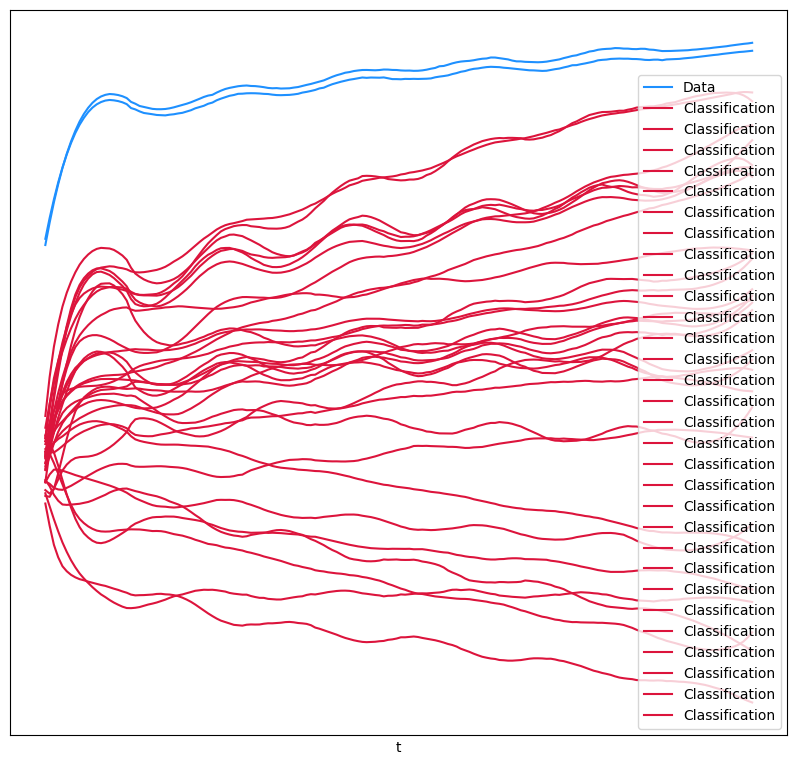

In [ ]:
# Training loop like normal.
### Model Instantiation ###
# NeuralCDEV2 is a class that takes in an (N, T - 1, G) tensor and the network architecture params.
# When instantiated (as done below)
model_sim = NeuralCDE(data_size = X_waveforms.shape[-1],
                      hidden_size = HIDDEN_SIZE,
                      width_size = WIDTH_SIZE,
                      output_size = OUTPUT_SIZE,
                      depth = DEPTH,
                      key = model_key)

### FUNCTIONS ###
def ncde_predict(model, ti, coeff_i, evolving_out = False):
    if evolving_out:
        def model_evolving(ts, coeffs):
            return model(ts, coeffs, evolving_out = True)
        return jax.vmap(model_evolving)(ti, coeff_i)
    else:
        return jax.vmap(model)(ti, coeff_i)

def compute_mse(y_true, y_pred, epsilon=1e-15):
    """
    MSE Loss for forecasting with real numbers
    """
    # if y_true.ndim == 3:
    #     y_true = y_true[:, 0, :]

    # Ensure predictions are clipped to avoid log(0)
    # y_pred = jnp.clip(y_pred, epsilon, 1 - epsilon)

    # Calculate the categorical cross-entropy
    # loss = jnp.mean(optax.l2_loss(y_pred, y_true))
    loss = jnp.mean((y_true - y_pred)**2, axis=1)

    # Return the mean loss over all samples
    return jnp.mean(loss)

@eqx.filter_jit
def loss(model, ti, y_true, coeff_i, evolving_out = False):
    pred = ncde_predict(model, ti, coeff_i, evolving_out = evolving_out)

    print(f"y_true: {y_true.shape}; y_pred: {pred.shape}.")

    # MSE
    mse_val = compute_mse(y_true = y_true, y_pred = pred)

    # mse_val = jnp.mean(mse_val)

    return mse_val, mse_val

# has_aux true will return two values: output to be differentiated and its gradient
grad_loss = eqx.filter_value_and_grad(loss, has_aux=True)

@eqx.filter_jit
def make_step(model, data_i, opt_state):
    ti, label_i, label_all_i, *coeff_i = data_i

    (mse_val, _), grads = grad_loss(model, ti, label_all_i, coeff_i, evolving_out = True)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return mse_val, model, opt_state

# Data Processing Functions
def dataloader(arrays, batch_size, *, key):
    dataset_size = arrays[0].shape[0]
    assert all(array.shape[0] == dataset_size for array in arrays)
    indices = jnp.arange(dataset_size)
    while True:
        perm = jr.permutation(key, indices)
        (key,) = jr.split(key, 1)
        start = 0
        end = batch_size
        while end < dataset_size:
            batch_perm = perm[start:end]
            yield tuple(array[batch_perm] for array in arrays)
            start = end
            end = start + batch_size


### EXECUTION ###
# Optional section
optim = optax.adam(1e-4)
opt_state = optim.init(eqx.filter(model_sim, eqx.is_inexact_array))
for step, data_i in zip(
    range(steps), dataloader((t_mat2d, y_waveforms, y_waveforms_evol) + coeffs, BATCH_SIZE, key=loader_key)
):
    start = time.time()
    mse_val, model_sim, opt_state = make_step(model_sim, data_i, opt_state)
    end = time.time()
    print(
        f"Step: {step}, Loss: {mse_val}, Accuracy: {mse_val}, Computation time: "
        f"{end - start}"
    )

# ts, coeffs, labels, _ = get_data(dataset_size, add_noise, key=test_data_key)
(mse_val, _) = loss(model = model_sim,
                    ti = t_mat2d,
                    y_true = y_waveforms,
                    coeff_i = coeffs)
print(f"Test loss: {mse_val}, Test Accuracy: {mse_val}")

# Plot results : Data Preparation for Plotting
sample_ts = t_mat2d[-1] # gets the last waveform in the dataset [size: (N_TIMEPOINTS - 1,)]
# coeffs is a list of four tensors for each cubic spliene coefficient,
# so we get, for each coefficient tensor, the last row which is the coefficients of the last tensor
sample_coeffs = tuple(c[-1] for c in coeffs)
# Get predictions for that waveform
pred = model_sim(sample_ts, sample_coeffs, evolving_out=True)
# This interpolates data for the coefficients
interp = diffrax.CubicInterpolation(sample_ts, sample_coeffs)
# Evaluates sample time series for the actual values
values = jax.vmap(interp.evaluate)(sample_ts)

# Plot 1
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(1, 2, 1)

ax1.plot(sample_ts, values[:, 1], c="dodgerblue")
ax1.plot(sample_ts, values[:, 2], c="dodgerblue", label="Data")
ax1.plot(sample_ts, pred, c="crimson", label="Classification")
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_xlabel("t")
ax1.legend()

# Plot 2
# ax2 = fig.add_subplot(1, 2, 2, projection="3d")
# ax2.plot(values[:, 1], values[:, 2], c="dodgerblue", label="Data")
# ax2.plot(values[:, 1], values[:, 2], pred[:, 1], c="crimson", label="Classification")
# ax2.set_xticks([])
# ax2.set_yticks([])
# ax2.set_zticks([])
# ax2.set_xlabel("x")
# ax2.set_ylabel("y")
# ax2.set_zlabel("Classification")
plt.tight_layout()
plt.savefig("neural_cde.png")
plt.show()

## Train-test split